In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools

In [2]:
torch.cuda.is_available()

True

In [3]:
ransomware = set(["WannaCry", "Ryuk", "REvil", "LockBit", "Darkside", "Conti"])

In [4]:
orig_df = pd.read_pickle('all_sys_config_10s_1s.pkl')

In [5]:
# df = pd.read_pickle('processed_dataset/final_dataset_new_features_all_logs_10s_window.pkl')
df = pd.read_pickle('all_sys_config_10s_1s.pkl')
df['start_s'] = df['start'].apply(lambda x: x.seconds)
df['end_s'] = df['end'].apply(lambda x: x.seconds)

In [6]:
df.columns

Index(['start', 'end', 'avg_ata_read', 'avg_ata_write', 'lba_read_var',
       'lba_write_var', 'avg_storage_entropy', 'avg_entropy_mem_write',
       'avg_entropy_mem_read_write', 'num_4KB_pages_mem_read',
       ...
       'mem_exec_access_locality', 'mem_exec_frwrd_bckwrd_ratio',
       'mem_exec_gpa_range', 'is_ransomware', 'operation', 'execution_id',
       'execution_log_cnt', 'sys_config', 'start_s', 'end_s'],
      dtype='object', length=113)

In [7]:
# remove mix
df = df[~df['sys_config'].str.contains('mix')]

In [8]:
df = df.sort_values(by=['sys_config', 'operation', 'execution_log_cnt', 'start_s']).reset_index(drop=True)

In [9]:
df.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,execution_id,execution_log_cnt,sys_config,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,3535513.6,862771.2,8.227914e+14,1.480098e+15,0.488477,0.009859,0.769090,16.0,...,1.0,1.000000,1.956988e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,0,10
1,0 days 00:00:01,0 days 00:00:11,4706969.6,966809.6,6.897555e+14,1.668981e+15,0.498426,0.009550,0.808229,9.0,...,1.0,0.750000,1.937112e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,1,11
2,0 days 00:00:02,0 days 00:00:12,4933632.0,1436620.8,6.893165e+14,2.360246e+15,0.609265,0.008803,0.771016,9.0,...,1.0,1.333333,1.937112e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,2,12
3,0 days 00:00:03,0 days 00:00:13,9907865.6,2446643.2,3.884602e+14,2.456015e+15,0.636874,0.010777,0.767203,9.0,...,1.0,1.666667,1.357491e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,3,13
4,0 days 00:00:04,0 days 00:00:14,14008320.0,3856076.8,3.511144e+14,2.555528e+15,0.663654,0.015945,0.767203,9.0,...,1.0,1.666667,1.357491e+10,False,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,4,14


# Null Imputation and Feature Selection

In [10]:
def timedelta_to_ns(t):
    if type(t) == pd.Timedelta:
        return t.total_seconds() * 1e9 + t.nanoseconds
    else:
        return t.total_seconds() * 1e9

## Feature Selection

In [11]:
non_target_features = ['start', 'end']

# Obtained in EDA notebook
zero_var_features = ['num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec', 'mem_exec_burst_clustering', 'mem_write_seq_addr_access_ratio', 'mem_read_write_seq_addr_access_ratio']

high_corr_features = ['mem_exec_seq_addr_access_ratio', 'num_MMIO_pages_mem_write', 'strg_read_event_rate', 'strg_write_event_rate', 'mem_read_burst_intensity', 'mem_read_event_rate', 'mem_write_burst_intensity',
 'mem_write_event_rate', 'mem_read_write_micro_burst_count', 'mem_read_write_event_rate', 'mem_exec_burst_intensity', 'mem_exec_event_rate', 'strg_read_lba_range', 'strg_write_lba_range',
 'mem_read_gpa_range', 'mem_write_gpa_range', 'mem_read_write_gpa_range', 'mem_exec_avg_gpa_jump', 'mem_exec_gpa_range', 'end_s']

In [12]:
df = df.drop(columns= zero_var_features + high_corr_features)

## Null Imputation

In [15]:
df["is_ransomware"] = df["is_ransomware"].astype(int)

window_delta = df.iloc[0]['end'] - df.iloc[0]['start']
step_delta = df[(df['operation']=='AESCrypt') & (df['execution_log_cnt']==0)]['start'].diff()[1]

time_to_high_entropy_cols = [col for col in df.columns if 'time_to_high_entropy' in col]
# Fill null values in time cols with (window_size + step)
df[time_to_high_entropy_cols] = df[time_to_high_entropy_cols].fillna(timedelta_to_ns(window_delta+step_delta))
df = df.fillna(0)


In [16]:
df = df.drop(columns=non_target_features)

# Preprocess

## Trim Dataset

In [ ]:
df = df[df['execution_id'] != 'WannaCry-20221214_14-28-57'] # This execution has very small execution time. So remove it

## Dataset Loader

In [ ]:
class RansomwareDataset(Dataset):
    def __init__(self, df, feature_columns, pad_to_length=None, pad_value=0.0):
        """
        Args:
            df: DataFrame
            feature_columns: List of 81 feature column names
            pad_to_length: Fixed length to pad all sequences to (default: max length in dataset)
            pad_value: Value to use for padding (default: 0.0)
        """
        self.feature_columns = feature_columns
        self.pad_value = pad_value
        
        self.sequences = []
        self.labels = []
        self.lengths = []
        self.metadata = []
        
        groupby_cols = ['sys_config', 'operation', 'execution_log_cnt']
        
        for (config, app, exec_id), group in df.groupby(groupby_cols):
            group = group.sort_values('start_s')
            
            features = group[feature_columns].values  # (num_wind, 81)
            label = group['is_ransomware'].iloc[0]
            original_length = len(features)
            
            self.sequences.append(features)
            self.labels.append(label)
            self.lengths.append(original_length)
            self.metadata.append({
                'system_config': config,
                'application': app,
                'execution_id': exec_id,
                'original_length': original_length
            })
        
        # print("Created sequences")
        if pad_to_length is None:
            self.pad_to_length = max(self.lengths)
        else:
            self.pad_to_length = pad_to_length
        
        # print(f"Performing padding with length: {self.pad_to_length}")
        self.sequences_padded = self._pad_sequences()
        # print("Finished padding")
        self.sequences_padded = np.array(self.sequences_padded, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)
        self.lengths = np.array(self.lengths, dtype=np.int64)
        
        print(f"{'-'*70}")
        print(f"DATASET SUMMARY")
        print(f"{'-'*70}")
        print(f"Total sequences: {len(self.sequences_padded)}")
        print(f"Sequence lengths: min={min(self.lengths)}, max={max(self.lengths)}, "
              f"mean={np.mean(self.lengths):.1f}")
        print(f"Padded sequence shape: {self.sequences_padded.shape}")
        print(f"  - Batch dimension: variable (set by DataLoader)")
        print(f"  - Sequence dimension: {self.pad_to_length}")
        print(f"  - Feature dimension: {len(feature_columns)}")
        print(f"Class distribution:")
        print(f"  - Benign: {np.sum(self.labels == 0)}")
        print(f"  - Ransomware: {np.sum(self.labels == 1)}")
        if 'hardware_config' in self.metadata[0]:
            hw_counts = pd.Series([m['hardware_config'] for m in self.metadata]).value_counts()
            print(f"Hardware distribution:")
            for hw, count in hw_counts.items():
                print(f"  - {hw}: {count}")
        print(f"{'-'*70}\n")
    
    def _pad_sequences(self):
        """Pad all sequences to the same length"""
        padded_sequences = []
        
        for seq in self.sequences:
            current_length = len(seq)
            
            if current_length < self.pad_to_length:
                pad_length = self.pad_to_length - current_length
                padding = np.full((pad_length, seq.shape[1]), self.pad_value)
                padded_seq = np.vstack([seq, padding])
            elif current_length > self.pad_to_length:
                padded_seq = seq[:self.pad_to_length]
            else:
                padded_seq = seq
            
            padded_sequences.append(padded_seq)
        
        return padded_sequences
    
    def __len__(self):
        return len(self.sequences_padded)
    
    def __getitem__(self, idx):
        """
        Returns:
            sequence: Padded sequence tensor (pad_to_length, num_features)
            label: Binary label (0 or 1)
            length: Original sequence length before padding
        """
        sequence = torch.tensor(self.sequences_padded[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        length = torch.tensor(self.lengths[idx], dtype=torch.long)
        
        return sequence, label, length

In [19]:
feature_cols = df.drop(columns=['is_ransomware', 'operation', 'execution_log_cnt', 'sys_config', 'execution_id']).columns.to_list()
feature_cols

['avg_ata_read',
 'avg_ata_write',
 'lba_read_var',
 'lba_write_var',
 'avg_storage_entropy',
 'avg_entropy_mem_write',
 'avg_entropy_mem_read_write',
 'num_4KB_pages_mem_read',
 'num_4KB_pages_mem_write',
 'num_4KB_pages_mem_read_write',
 'num_4KB_pages_mem_exec',
 'num_2MB_pages_mem_read',
 'num_2MB_pages_mem_write',
 'num_2MB_pages_mem_read_write',
 'num_2MB_pages_mem_exec',
 'num_MMIO_pages_mem_read',
 'gpa_mem_read_var',
 'gpa_mem_write_var',
 'gpa_mem_read_write_var',
 'gpa_mem_exec_var',
 'strg_write_high_entropy_count',
 'strg_write_max_entropy_jump',
 'strg_write_time_to_high_entropy',
 'strg_write_sustained_high_entropy_events',
 'strg_write_entropy_acceleration',
 'mem_write_high_entropy_count',
 'mem_write_max_entropy_jump',
 'mem_write_time_to_high_entropy',
 'mem_write_sustained_high_entropy_events',
 'mem_write_entropy_acceleration',
 'mem_read_write_high_entropy_count',
 'mem_read_write_max_entropy_jump',
 'mem_read_write_time_to_high_entropy',
 'mem_read_write_sustaine

In [ ]:
def prepare_data(df, feature_columns, Td, test_apps, batch_size=16, shuffle=True):        
    if test_apps is not None:
        train_df = df[~df['operation'].isin(test_apps)].copy()
        test_df = df[df['operation'].isin(test_apps)].copy()
    else:
        train_df = df[~(df['sys_config'].str.contains('extra'))].copy()
        test_df = df[df['sys_config'].str.contains('extra')].copy()
    
    print(f"\n{'='*70}")
    print(f"DATA SPLIT for {'unseen' if test_apps is not None else 'seen'} with Td={Td}")
    print(f"{'='*70}")
    # print(f"Training applications: {train_apps}")
    print(f"Testing applications: {test_apps if test_apps is not None else 'all'}")
    print(f"Training executions: {len(train_df.groupby(['sys_config', 'operation', 'execution_log_cnt']))}")
    print(f"Testing executions: {len(test_df.groupby(['sys_config', 'operation', 'execution_log_cnt']))}")
    print(f"{'='*70}\n")
    
    scaler = StandardScaler()
    train_df[feature_columns] = scaler.fit_transform(train_df[feature_columns])
    test_df[feature_columns] = scaler.transform(test_df[feature_columns])
    
    # Create datasets
    train_dataset = RansomwareDataset(train_df, feature_columns, Td)
    test_dataset = RansomwareDataset(test_df, feature_columns, Td)
    
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    if not shuffle:
        return train_loader, test_loader, scaler, train_dataset, test_dataset
    
    return train_loader, test_loader, scaler


In [117]:
df['sys_config'].unique()

array(['extra_i3-gen12_ddr5-4800-16g', 'extra_i5-gen12_ddr4-2133-16g',
       'extra_i7-gen12_ddr4-2133-16g',
       'original_celeron-gen6_ddr4-1600-16g',
       'original_celeron-gen6_ddr4-1600-8g',
       'original_celeron-gen6_ddr4-1866-16g',
       'original_celeron-gen6_ddr4-1866-8g',
       'original_celeron-gen6_ddr4-2133-16g',
       'original_celeron-gen6_ddr4-2133-8g',
       'original_i3-gen12_ddr4-2133-16g',
       'original_i3-gen12_ddr4-2133-8g',
       'original_i3-gen12_ddr4-2666-16g',
       'original_i3-gen12_ddr4-2666-8g',
       'original_i3-gen12_ddr4-3200-16g',
       'original_i3-gen12_ddr4-3200-8g'], dtype=object)

In [21]:
benign_apps = ['AESCrypt', 'Firefox', 'Idle', 'Office', 'SDelete', 'Zip']
ransomware_apps = ['Conti', 'Darkside', 'LockBit', 'REvil', 'Ryuk', 'WannaCry']

# train_apps = benign_apps[:-1] + ransomware_apps[:-1]  # 10 apps
test_apps = [benign_apps[-1], ransomware_apps[-1]]     # 2 apps
test_apps

['Zip', 'WannaCry']

In [254]:
tmp_train_df = df[~df['operation'].isin(test_apps)].copy()
tmp_test_df = df[df['operation'].isin(test_apps)].copy()

In [177]:
df.head()

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,mem_read_write_frwrd_bckwrd_ratio,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,is_ransomware,operation,execution_id,execution_log_cnt,sys_config,start_s
0,3535513.6,862771.2,8.227914e+14,1.480098e+15,0.488477,0.009859,0.769090,16.0,0.0,0.0,...,0.952381,1.937112e+10,1.0,1.000000,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,0
1,4706969.6,966809.6,6.897555e+14,1.668981e+15,0.498426,0.009550,0.808229,9.0,0.0,0.0,...,0.833333,1.937112e+10,1.0,0.750000,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,1
2,4933632.0,1436620.8,6.893165e+14,2.360246e+15,0.609265,0.008803,0.771016,9.0,0.0,0.0,...,0.444444,1.937112e+10,1.0,1.333333,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,2
3,9907865.6,2446643.2,3.884602e+14,2.456015e+15,0.636874,0.010777,0.767203,9.0,0.0,0.0,...,0.571429,1.272560e+10,1.0,1.666667,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,3
4,14008320.0,3856076.8,3.511144e+14,2.555528e+15,0.663654,0.015945,0.767203,9.0,0.0,0.0,...,0.571429,1.272560e+10,1.0,1.666667,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,4


In [24]:
train_dataloader_unseen_10s, test_dataloader_unseen_10s, scaler_unseen_10s = prepare_data(df, feature_cols, 10, test_apps)
train_dataloader_unseen_20s, test_dataloader_unseen_20s, scaler_unseen_20s = prepare_data(df, feature_cols, 20, test_apps)
train_dataloader_unseen_30s, test_dataloader_unseen_30s, scaler_unseen_30s = prepare_data(df, feature_cols, 30, test_apps)
train_dataloader_unseen_60s, test_dataloader_unseen_60s, scaler_unseen_60s = prepare_data(df, feature_cols, 60, test_apps)
train_dataloader_unseen_90s, test_dataloader_unseen_90s, scaler_unseen_90s = prepare_data(df, feature_cols, 90, test_apps)
train_dataloader_unseen_120s, test_dataloader_unseen_120s, scaler_unseen_120s = prepare_data(df, feature_cols, 120, test_apps)
train_dataloader_unseen_150s, test_dataloader_unseen_150s, scaler_unseen_150s = prepare_data(df, feature_cols, 150, test_apps)
train_dataloader_unseen_180s, test_dataloader_unseen_180s, scaler_unseen_180s = prepare_data(df, feature_cols, 180, test_apps)

train_dataloader_seen_10s, test_dataloader_seen_10s, scaler_seen_10s = prepare_data(df, feature_cols, 10, None)
train_dataloader_seen_20s, test_dataloader_seen_20s, scaler_seen_20s = prepare_data(df, feature_cols, 20, None)
train_dataloader_seen_30s, test_dataloader_seen_30s, scaler_seen_30s = prepare_data(df, feature_cols, 30, None)
train_dataloader_seen_60s, test_dataloader_seen_60s, scaler_seen_60s = prepare_data(df, feature_cols, 60, None)
train_dataloader_seen_90s, test_dataloader_seen_90s, scaler_seen_90s = prepare_data(df, feature_cols, 90, None)
train_dataloader_seen_120s, test_dataloader_seen_120s, scaler_seen_120s = prepare_data(df, feature_cols, 120, None)
train_dataloader_seen_150s, test_dataloader_seen_150s, scaler_seen_150s = prepare_data(df, feature_cols, 150, None)
train_dataloader_seen_180s, test_dataloader_seen_180s, scaler_seen_180s = prepare_data(df, feature_cols, 180, None)



DATA SPLIT for unseen with Td=10
Testing applications: ['Zip', 'WannaCry']
Training executions: 1499
Testing executions: 298

----------------------------------------------------------------------
DATASET SUMMARY
----------------------------------------------------------------------
Total sequences: 1499
Sequence lengths: min=119, max=312, mean=188.1
Padded sequence shape: (1499, 10, 81)
  - Batch dimension: variable (set by DataLoader)
  - Sequence dimension: 10
  - Feature dimension: 81
Class distribution:
  - Benign: 750
  - Ransomware: 749
----------------------------------------------------------------------

----------------------------------------------------------------------
DATASET SUMMARY
----------------------------------------------------------------------
Total sequences: 298
Sequence lengths: min=166, max=269, mean=187.8
Padded sequence shape: (298, 10, 81)
  - Batch dimension: variable (set by DataLoader)
  - Sequence dimension: 10
  - Feature dimension: 81
Class distr

In [ ]:
train_dataloader_unseen_180s, test_dataloader_unseen_180s, scaler_unseen_180s = prepare_data(df, feature_cols, 180, test_apps)

### VAE

In [ ]:
def prepare_vae_data(df, feature_columns, Td, ransomware_apps, batch_size=16):

    vae_train_df = df[(~df['operation'].isin(ransomware_apps)) & (~df['sys_config'].str.contains('extra'))].copy()
    vae_val_df = df[(~df['operation'].isin(ransomware_apps)) & (df['sys_config'].str.contains('extra'))].copy()
    vae_test_df = df[(df['operation'].isin(ransomware_apps))].copy()

    
    print(f"\n{'='*70}")
    print(f"DATA SPLIT for VAE with Td={Td}")
    print(f"{'='*70}")
    print(f"Training executions: {len(vae_train_df.groupby(['sys_config', 'operation', 'execution_log_cnt']))}")
    print(f"Validation executions: {len(vae_val_df.groupby(['sys_config', 'operation', 'execution_log_cnt']))}")
    print(f"Testing executions: {len(vae_test_df.groupby(['sys_config', 'operation', 'execution_log_cnt']))}")
    print(f"{'='*70}\n")
    
    scaler = StandardScaler()
    vae_train_df[feature_columns] = scaler.fit_transform(vae_train_df[feature_columns])
    vae_val_df[feature_columns] = scaler.transform(vae_val_df[feature_columns])
    vae_test_df[feature_columns] = scaler.transform(vae_test_df[feature_columns])
    
    train_dataset = RansomwareDataset(vae_train_df, feature_columns, Td)
    val_dataset = RansomwareDataset(vae_val_df, feature_columns, Td)
    test_dataset = RansomwareDataset(vae_test_df, feature_columns, Td)
    
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, scaler

In [303]:
train_dataloader_vae_10s, val_dataloader_vae_10s, test_dataloader_vae_10s, scaler_vae_10s = prepare_vae_data(df, feature_cols, 10, ransomware_apps)
train_dataloader_vae_20s, val_dataloader_vae_20s, test_dataloader_vae_20s, scaler_vae_20s = prepare_vae_data(df, feature_cols, 20, ransomware_apps)
train_dataloader_vae_30s, val_dataloader_vae_30s, test_dataloader_vae_30s, scaler_vae_30s = prepare_vae_data(df, feature_cols, 30, ransomware_apps)
train_dataloader_vae_60s, val_dataloader_vae_60s, test_dataloader_vae_60s, scaler_vae_60s = prepare_vae_data(df, feature_cols, 60, ransomware_apps)
train_dataloader_vae_90s, val_dataloader_vae_90s, test_dataloader_vae_90s, scaler_vae_90s = prepare_vae_data(df, feature_cols, 90, ransomware_apps)
train_dataloader_vae_120s, val_dataloader_vae_120s, test_dataloader_vae_120s, scaler_vae_120s = prepare_vae_data(df, feature_cols, 120, ransomware_apps)
train_dataloader_vae_150s, val_dataloader_vae_150s, test_dataloader_vae_150s, scaler_vae_150s = prepare_vae_data(df, feature_cols, 150, ransomware_apps)
train_dataloader_vae_180s, val_dataloader_vae_180s, test_dataloader_vae_180s, scaler_vae_180s = prepare_vae_data(df, feature_cols, 180, ransomware_apps)


DATA SPLIT for VAE with Td=10
Training executions: 720
Validation executions: 180
Testing executions: 897

----------------------------------------------------------------------
DATASET SUMMARY
----------------------------------------------------------------------
Total sequences: 720
Sequence lengths: min=119, max=312, mean=183.7
Padded sequence shape: (720, 10, 81)
  - Batch dimension: variable (set by DataLoader)
  - Sequence dimension: 10
  - Feature dimension: 81
Class distribution:
  - Benign: 720
  - Ransomware: 0
----------------------------------------------------------------------

----------------------------------------------------------------------
DATASET SUMMARY
----------------------------------------------------------------------
Total sequences: 180
Sequence lengths: min=169, max=218, mean=180.9
Padded sequence shape: (180, 10, 81)
  - Batch dimension: variable (set by DataLoader)
  - Sequence dimension: 10
  - Feature dimension: 81
Class distribution:
  - Benign: 18

In [314]:
len(test_dataloader_vae_10s)

57

In [313]:
for sequences, _, _ in test_dataloader_vae_10s:
    print(type(sequences), sequences.shape)
    # break

<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 10, 81])
<class 'torch.Tensor'> torch.Size([16, 1

In [ ]:
# tmp_vae_train_df = df[(~df['operation'].isin(ransomware_apps)) & (~df['sys_config'].str.contains('extra'))]
# tmp_vae_val_df = df[(~df['operation'].isin(ransomware_apps)) & (df['sys_config'].str.contains('extra'))]
# tmp_vae_test_df = df[(df['operation'].isin(ransomware_apps))]
# tmp_vae_train_df['operation'].unique(), tmp_vae_train_df['sys_config'].unique()

In [ ]:
# tmp_vae_val_df['operation'].unique(), tmp_vae_val_df['sys_config'].unique()

In [ ]:
# tmp_vae_test_df['operation'].unique(), tmp_vae_test_df['sys_config'].unique()

In [115]:
df.head()

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,mem_read_write_frwrd_bckwrd_ratio,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,is_ransomware,operation,execution_id,execution_log_cnt,sys_config,start_s
0,3535513.6,862771.2,8.227914e+14,1.480098e+15,0.488477,0.009859,0.769090,16.0,0.0,0.0,...,0.952381,1.937112e+10,1.0,1.000000,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,0
1,4706969.6,966809.6,6.897555e+14,1.668981e+15,0.498426,0.009550,0.808229,9.0,0.0,0.0,...,0.833333,1.937112e+10,1.0,0.750000,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,1
2,4933632.0,1436620.8,6.893165e+14,2.360246e+15,0.609265,0.008803,0.771016,9.0,0.0,0.0,...,0.444444,1.937112e+10,1.0,1.333333,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,2
3,9907865.6,2446643.2,3.884602e+14,2.456015e+15,0.636874,0.010777,0.767203,9.0,0.0,0.0,...,0.571429,1.272560e+10,1.0,1.666667,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,3
4,14008320.0,3856076.8,3.511144e+14,2.555528e+15,0.663654,0.015945,0.767203,9.0,0.0,0.0,...,0.571429,1.272560e+10,1.0,1.666667,0,AESCrypt,AESCrypt-20240228_10-57-21,0,extra_i3-gen12_ddr5-4800-16g,4


In [116]:
df['sys_config'].unique()

array(['extra_i3-gen12_ddr5-4800-16g', 'extra_i5-gen12_ddr4-2133-16g',
       'extra_i7-gen12_ddr4-2133-16g',
       'original_celeron-gen6_ddr4-1600-16g',
       'original_celeron-gen6_ddr4-1600-8g',
       'original_celeron-gen6_ddr4-1866-16g',
       'original_celeron-gen6_ddr4-1866-8g',
       'original_celeron-gen6_ddr4-2133-16g',
       'original_celeron-gen6_ddr4-2133-8g',
       'original_i3-gen12_ddr4-2133-16g',
       'original_i3-gen12_ddr4-2133-8g',
       'original_i3-gen12_ddr4-2666-16g',
       'original_i3-gen12_ddr4-2666-8g',
       'original_i3-gen12_ddr4-3200-16g',
       'original_i3-gen12_ddr4-3200-8g'], dtype=object)

# Models

## CNN

In [ ]:
class SimpleCNN1D(nn.Module):
    def __init__(self, input_size=81, num_filters=64, dropout=0.3):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv1d(input_size, num_filters, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(dropout),
            
            nn.Conv1d(num_filters, num_filters*2, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(dropout),
            
            nn.Conv1d(num_filters*2, num_filters*4, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_filters*4),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_filters*4, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x, lengths=None):
        """
        Args:
            x: (batch_size, 171, 81)
        Returns:
            output: (batch_size, 1)
        """
        x = x.transpose(1, 2)  # (batch, 81, 171)
        
        x = self.conv_layers(x)  # (batch, num_filters*4, 1)
        
        x = x.squeeze(-1)  # (batch, num_filters*4)
        
        output = self.classifier(x)
        
        return output

In [ ]:
model = SimpleCNN1D(input_size=len(feature_cols))
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: SimpleCNN1D")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Model: SimpleCNN1D
Total parameters: 248,577
Trainable parameters: 248,577

Model architecture:
SimpleCNN1D(
  (conv_layers): Sequential(
    (0): Conv1d(81, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
    (5): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
    (11): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveMaxPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Dr

## LSTM

In [ ]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=81, hidden_size=64, num_layers=1, dropout=0.3):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=0)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x, lengths=None):
        lstm_out, (h_n, c_n) = self.lstm(x)
        final_hidden = h_n[-1]
        output = self.classifier(final_hidden)
        return output
    

## TCN

In [282]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size]

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2,
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(self, input_size=81, num_channels=[64, 64, 128], kernel_size=5, dropout=0.3):
        super().__init__()
        layers = []
        in_ch = input_size
        for out_ch in num_channels:
            layers.append(
                TemporalBlock(
                    in_ch, out_ch, kernel_size,
                    stride=1, dilation=1, padding=(kernel_size-1),
                    dropout=dropout,
                )
            )
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(num_channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, lengths=None):
        x = x.transpose(1, 2)  # (batch, channels, time)
        features = self.tcn(x)
        return self.classifier(features)


## LSTM VAE

In [ ]:
class LSTM_VAE(nn.Module):
    def __init__(self, input_size=81, hidden_size=64, latent_size=32, num_layers=1):
        super().__init__()

        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers

        # Encoder
        self.encoder_lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc_mu = nn.Linear(hidden_size, latent_size)
        self.fc_logvar = nn.Linear(hidden_size, latent_size)

        # Decoder
        self.decoder_fc = nn.Linear(latent_size, hidden_size)
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc_output = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h = h_n[-1]
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, seq_len):
        h0 = self.decoder_fc(z).unsqueeze(0)
        h0 = h0.repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)

        x = torch.zeros((z.size(0), seq_len, self.hidden_size), device=z.device)

        decoded, _ = self.decoder_lstm(x, (h0, c0))
        out = self.fc_output(decoded)
        return out

    def forward(self, x):
        seq_len = x.size(1)

        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, seq_len)

        return recon, mu, logvar


# Training Pipeline

## Supervised

In [26]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_idx, (sequences, labels, lengths) in enumerate(dataloader):
        sequences = sequences.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device) if lengths is not None else None
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(sequences, lengths).squeeze()
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    avg_loss = total_loss / len(dataloader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, preds_binary),
        'precision': precision_score(all_labels, preds_binary, zero_division=0),
        'recall': recall_score(all_labels, preds_binary, zero_division=0),
        'f1': f1_score(all_labels, preds_binary, zero_division=0),
    }
    
    return metrics


def evaluate(model, dataloader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for sequences, labels, lengths in dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device) if lengths is not None else None
            
            # Forward pass
            outputs = model(sequences, lengths).squeeze()
            loss = criterion(outputs, labels)
            
            # Track metrics
            total_loss += loss.item()
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    avg_loss = total_loss / len(dataloader)
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        # 'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0
    }
    
    return metrics, all_preds, all_probs, all_labels


def train_model(model, train_loader, val_loader, epochs=100, device='cuda', 
                lr=0.001, patience=15, model_name='model'):
    """
    Complete training loop with early stopping
    """
    model = model.to(device)
    
    # os.makedirs('./model_data/tmp', exist_ok=True)
    save_dir = os.path.join('model_data', model_name)
    os.makedirs(save_dir, exist_ok=True)
    
    # Loss and optimizer
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    best_val_f1 = 0
    best_epoch = 0
    patience_counter = 0
    
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}")
    print(f"Device: {device}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"Learning rate: {lr}")
    print(f"{'='*70}\n")
    
    for epoch in range(epochs):
        # Train
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)
        
        # Update scheduler
        scheduler.step(val_metrics['loss'])
        
        # Save history
        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['train_f1'].append(train_metrics['f1'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        
        # Print progress
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_metrics['loss']:.4f} | "
              f"Train F1: {train_metrics['f1']:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Val F1: {val_metrics['f1']:.4f} | "
              f"Val Acc: {val_metrics['accuracy']:.4f}")
        
        # Early stopping based on F1 score
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_epoch = epoch
            patience_counter = 0
            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': best_val_f1,
                'val_metrics': val_metrics
            }, os.path.join(save_dir, 'best_model.pth'))
        else:
            patience_counter += 1
        
        # Check early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best validation F1: {best_val_f1:.4f} at epoch {best_epoch+1}")
            break
    
    # Load best model
    checkpoint = torch.load(os.path.join(save_dir, 'best_model.pth'))
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"\n{'='*70}")
    print(f"TRAINING COMPLETED")
    print(f"Best Epoch: {best_epoch+1}")
    print(f"Best Validation F1: {best_val_f1:.4f}")
    print(f"Best Validation Accuracy: {checkpoint['val_metrics']['accuracy']:.4f}")
    print(f"Best Validation Precision: {checkpoint['val_metrics']['precision']:.4f}")
    print(f"Best Validation Recall: {checkpoint['val_metrics']['recall']:.4f}")
    print(f"{'='*70}\n")
    
    return model, history


In [27]:
def plot_training_history(history, model_name='Model'):
    """Plot training history"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    save_dir = os.path.join('model_data', model_name)
    os.makedirs(save_dir, exist_ok=True)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # F1 Score
    axes[2].plot(epochs, history['train_f1'], 'b-', label='Train F1', linewidth=2)
    axes[2].plot(epochs, history['val_f1'], 'r-', label='Val F1', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('F1 Score', fontsize=12)
    axes[2].set_title(f'{model_name} - F1 Score', fontsize=14, fontweight='bold')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, predictions, model_name='Model'):
    """Plot confusion matrix"""
    cm = confusion_matrix(labels, predictions)
    
    save_dir = os.path.join('model_data', model_name)
    os.makedirs(save_dir, exist_ok=True)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'Ransomware'],
                yticklabels=['Benign', 'Ransomware'],
                cbar_kws={'label': 'Count'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print metrics
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{model_name} Confusion Matrix:")
    print(f"True Negatives (Benign correctly identified): {tn}")
    print(f"False Positives (Benign misclassified as Ransomware): {fp}")
    print(f"False Negatives (Ransomware misclassified as Benign): {fn}")
    print(f"True Positives (Ransomware correctly identified): {tp}")

In [28]:
def train_and_evaluate(model, train_loader, test_loader, model_name, epochs, lr=0.001, patience=15):
    # 2. Train the model
    trained_model, history = train_model(
        model, 
        train_loader, 
        test_loader,  # Using test_loader as validation
        epochs=epochs,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        lr=lr,
        patience=patience,
        model_name=model_name
    )


    # 3. Plot training history
    plot_training_history(history, model_name=model_name)

    # 4. Final evaluation on test set
    test_metrics, test_preds, test_probs, test_labels = evaluate(
        trained_model, 
        test_loader, 
        nn.BCEWithLogitsLoss(), 
        'cuda' if torch.cuda.is_available() else 'cpu'
    )

    print(f"\n{'='*70}")
    print(f"FINAL TEST SET RESULTS")
    print(f"{'='*70}")
    print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall:    {test_metrics['recall']:.4f}")
    print(f"F1-Score:  {test_metrics['f1']:.4f}")
    # print(f"AUC:       {test_metrics['auc']:.4f}")
    print(f"{'='*70}\n")

    # 5. Plot confusion matrix
    plot_confusion_matrix(test_labels, test_preds, model_name=model_name)
    
    return trained_model, history, test_metrics, test_preds, test_labels

In [ ]:
def plot_integrated_gradients_heatmap(model, test_loader):
    dataloader_iter = iter(test_loader)
    first_batch = next(dataloader_iter)
    ig = IntegratedGradients(model)
    sample = first_batch[0][0].unsqueeze(0).float().to('cuda' if torch.cuda.is_available() else 'cpu')
    ig_attributions = ig.attribute(sample)  # (T, F)
    plt.figure(figsize=(12,6))
    sns.heatmap(ig_attributions, cmap="viridis")
    plt.xlabel("Features")
    plt.ylabel("Time")
    plt.title("Integrated Gradients Feature Attribution (T x F)")
    plt.show()

In [ ]:
# len(ig_attributions), len(ig_attributions[0])

(10, 81)

## Unsupervised - Anomaly detection

In [321]:
for sequences, _, _ in test_dataloader_vae_10s:
    tmp_mean = torch.mean((sequences)**2)
    tmp_mean2 = torch.mean((sequences)**2, dim=(1,2))
    print(tmp_mean, sequences.shape, tmp_mean2.shape)
    break

tensor(4.9687) torch.Size([16, 10, 81]) torch.Size([16])


In [ ]:
def vae_loss(recon, x, mu, logvar):
    reconstruc_loss = nn.MSELoss()(recon, x)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruc_loss + kl_loss, reconstruc_loss, kl_loss

def train_vae_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    total_rec = 0
    total_kl = 0

    for batch_idx, (sequences, _, _) in enumerate(dataloader):  # ignore labels, lengths
        sequences = sequences.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(sequences)
        
        loss, reconstruc_loss, kl_loss = vae_loss(recon, sequences, mu, logvar)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_rec += reconstruc_loss.item()
        total_kl  += kl_loss.item()

    return {
        "loss": total_loss / len(dataloader),
        "reconstruction": total_rec / len(dataloader),
        "kl": total_kl / len(dataloader)
    }

def eval_vae(model, dataloader, device):
    model.eval()
    total_loss = 0
    total_rec = 0
    total_kl = 0
    
    reconstruc_losses = []
    kl_losses = []

    with torch.no_grad():
        for sequences, _, _ in dataloader:
            sequences = sequences.to(device)

            recon, mu, logvar = model(sequences)

            reconstruc_loss = torch.mean((recon - sequences)**2)
            per_seq_reconstruc_loss = torch.mean((recon - sequences)**2, dim=(1,2))  
            
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            per_seq_kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

            loss = reconstruc_loss + kl_loss

            total_loss += loss.item()
            total_rec += reconstruc_loss.item()
            total_kl  += kl_loss.item()
            
            reconstruc_losses.extend(per_seq_reconstruc_loss.cpu().numpy())
            kl_losses.extend(per_seq_kl_loss.cpu().numpy())

    return {
        "loss": total_loss / len(dataloader),
        "reconstruction": total_rec / len(dataloader),
        "kl": total_kl / len(dataloader),
        "reconstruction_losses": reconstruc_losses,
        "kl_losses": kl_losses
    }


def train_vae(model, dataloader, val_loader, device, epochs=50, model_name='lstm_vae'):
    model.to(device)
    
    save_dir = os.path.join('model_data', model_name)
    os.makedirs(save_dir, exist_ok=True)
    # os.path.join(save_dir, 'best_model.pth')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4
    )

    best_loss = float("inf")
    best_reconstruc_losses = []
    best_kl_losses = []
    
    patience_counter = 0
    patience = 10

    for epoch in range(epochs):
        train_metrics = train_vae_epoch(model, dataloader, optimizer, device)
        val_metrics = eval_vae(model, val_loader, device)

        scheduler.step(val_metrics["loss"])

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Recon: {val_metrics['reconstruction']:.4f}"
        )

        if val_metrics["loss"] < best_loss:
            best_loss = val_metrics["loss"]
            best_reconstruc_losses = val_metrics['reconstruction_losses']
            best_kl_losses = val_metrics['kl_losses']
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(save_dir, "vae_best.pth"))
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(os.path.join(save_dir, "vae_best.pth")))
    return model, best_reconstruc_losses, best_kl_losses


# Model Training

## Seen ransomware

#### CNN 1D


TRAINING CNN_1D_seen_10s
Device: cuda
Total parameters: 248,577
Trainable parameters: 248,577
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.4351 | Train F1: 0.8069 | Val Loss: 0.2995 | Val F1: 0.9013 | Val Acc: 0.8972
Epoch   2/100 | Train Loss: 0.2698 | Train F1: 0.9007 | Val Loss: 0.2172 | Val F1: 0.9223 | Val Acc: 0.9194
Epoch   3/100 | Train Loss: 0.2406 | Train F1: 0.9160 | Val Loss: 0.2227 | Val F1: 0.9188 | Val Acc: 0.9194
Epoch   4/100 | Train Loss: 0.1956 | Train F1: 0.9294 | Val Loss: 0.2574 | Val F1: 0.9148 | Val Acc: 0.9167
Epoch   5/100 | Train Loss: 0.1946 | Train F1: 0.9352 | Val Loss: 0.1872 | Val F1: 0.9415 | Val Acc: 0.9417
Epoch   6/100 | Train Loss: 0.1701 | Train F1: 0.9436 | Val Loss: 0.2216 | Val F1: 0.9243 | Val Acc: 0.9222
Epoch   7/100 | Train Loss: 0.1578 | Train F1: 0.9500 | Val Loss: 0.2584 | Val F1: 0.9488 | Val Acc: 0.9472
Epoch   8/100 | Train Loss: 0.1392 | Train F1: 0.9535 | Val Loss: 0.3135 | Val F1: 0.9217 | Val Acc: 0.9250
Epoch   9/100 | Tra

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

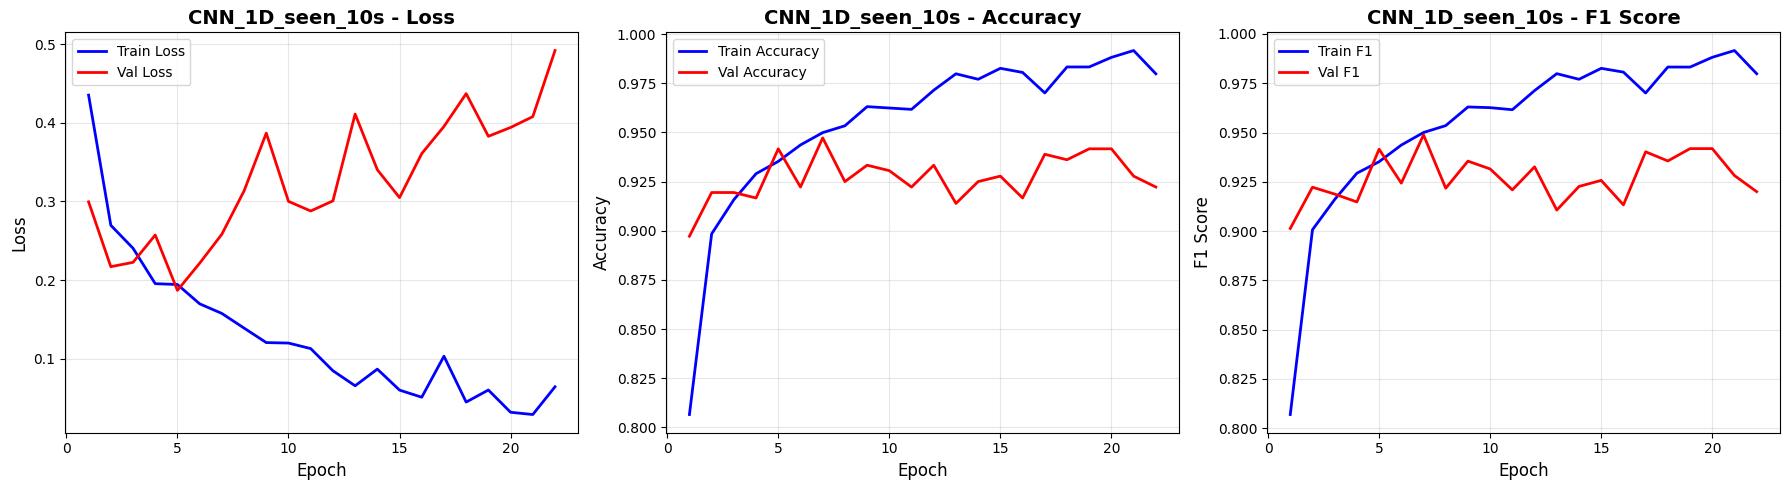


FINAL TEST SET RESULTS
Accuracy:  0.9472
Precision: 0.9215
Recall:    0.9778
F1-Score:  0.9488



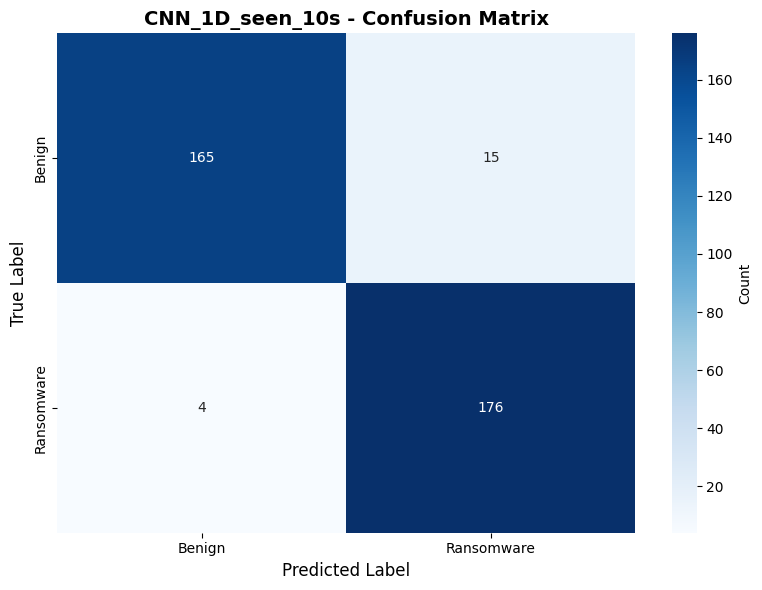


CNN_1D_seen_10s Confusion Matrix:
True Negatives (Benign correctly identified): 165
False Positives (Benign misclassified as Ransomware): 15
False Negatives (Ransomware misclassified as Benign): 4
True Positives (Ransomware correctly identified): 176


In [390]:
CNN_1D_model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
CNN_1D_seen_10s_trained_model, CNN_1D_seen_10s_history, CNN_1D_seen_10s_test_metrics, CNN_1D_seen_10s_test_preds, CNN_1D_seen_10s_test_labels = train_and_evaluate(CNN_1D_model, train_dataloader_seen_10s, test_dataloader_seen_10s, 'CNN_1D_seen_10s', epochs=100,)


TRAINING CNN_1D_seen_20s
Device: cuda
Total parameters: 248,577
Trainable parameters: 248,577
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.3533 | Train F1: 0.8397 | Val Loss: 0.2765 | Val F1: 0.9117 | Val Acc: 0.9139
Epoch   2/100 | Train Loss: 0.1956 | Train F1: 0.9345 | Val Loss: 0.1701 | Val F1: 0.9435 | Val Acc: 0.9444
Epoch   3/100 | Train Loss: 0.1295 | Train F1: 0.9584 | Val Loss: 0.3891 | Val F1: 0.8909 | Val Acc: 0.9000
Epoch   4/100 | Train Loss: 0.1292 | Train F1: 0.9591 | Val Loss: 0.1223 | Val F1: 0.9672 | Val Acc: 0.9667
Epoch   5/100 | Train Loss: 0.0910 | Train F1: 0.9676 | Val Loss: 0.1044 | Val F1: 0.9778 | Val Acc: 0.9778
Epoch   6/100 | Train Loss: 0.0753 | Train F1: 0.9741 | Val Loss: 0.1077 | Val F1: 0.9548 | Val Acc: 0.9556
Epoch   7/100 | Train Loss: 0.0772 | Train F1: 0.9709 | Val Loss: 0.1699 | Val F1: 0.9375 | Val Acc: 0.9389
Epoch   8/100 | Train Loss: 0.0582 | Train F1: 0.9811 | Val Loss: 0.1007 | Val F1: 0.9636 | Val Acc: 0.9639
Epoch   9/100 | Tra

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

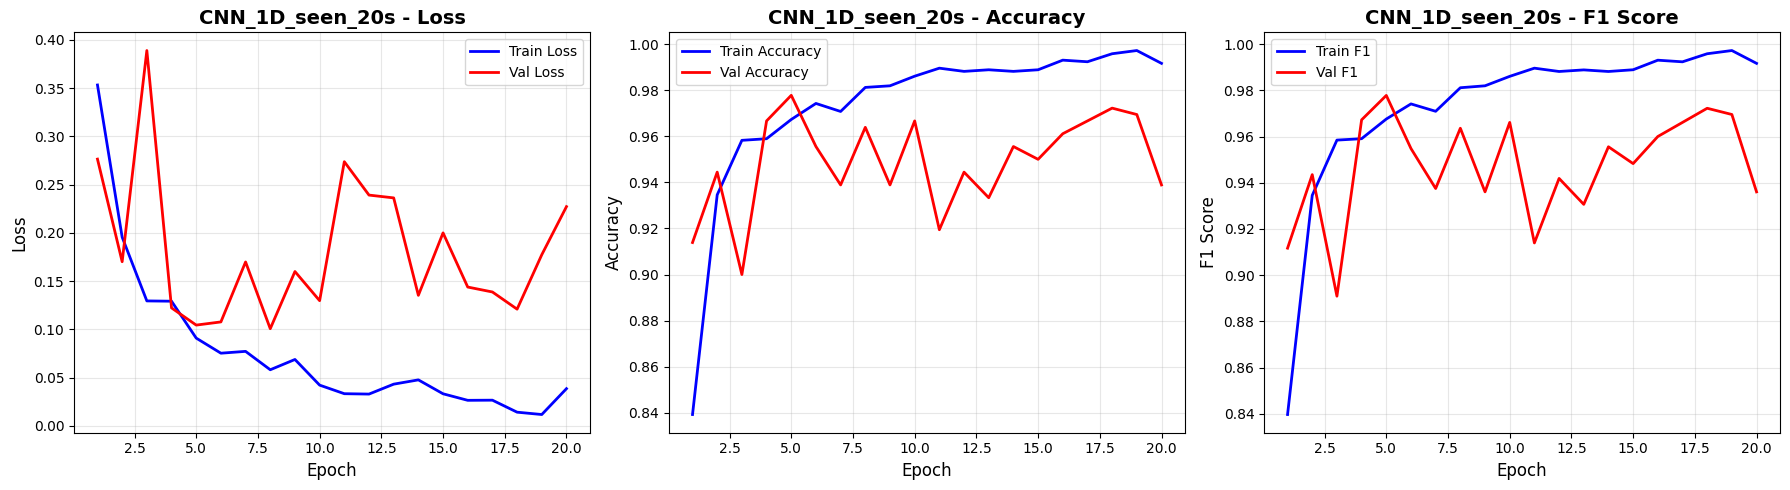


FINAL TEST SET RESULTS
Accuracy:  0.9778
Precision: 0.9778
Recall:    0.9778
F1-Score:  0.9778



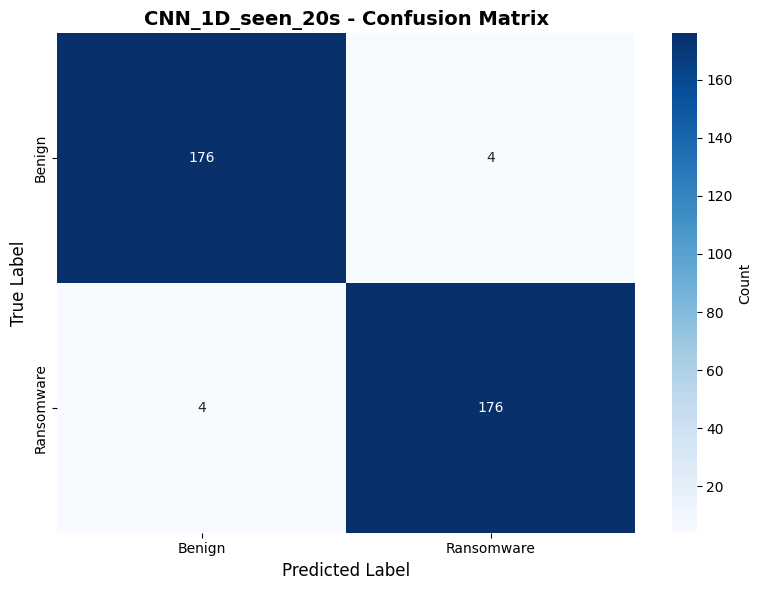


CNN_1D_seen_20s Confusion Matrix:
True Negatives (Benign correctly identified): 176
False Positives (Benign misclassified as Ransomware): 4
False Negatives (Ransomware misclassified as Benign): 4
True Positives (Ransomware correctly identified): 176


In [391]:
CNN_1D_model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
CNN_1D_seen_20s_trained_model, CNN_1D_seen_20s_history, CNN_1D_seen_20s_test_metrics, CNN_1D_seen_20s_test_preds, CNN_1D_seen_20s_test_labels = train_and_evaluate(CNN_1D_model, train_dataloader_seen_20s, test_dataloader_seen_20s, 'CNN_1D_seen_20s', epochs=100,)


TRAINING CNN_1D_seen_30s
Device: cuda
Total parameters: 248,577
Trainable parameters: 248,577
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.3297 | Train F1: 0.8534 | Val Loss: 0.6112 | Val F1: 0.8232 | Val Acc: 0.8472
Epoch   2/100 | Train Loss: 0.1186 | Train F1: 0.9592 | Val Loss: 0.1462 | Val F1: 0.9422 | Val Acc: 0.9444
Epoch   3/100 | Train Loss: 0.1253 | Train F1: 0.9589 | Val Loss: 0.1674 | Val F1: 0.9421 | Val Acc: 0.9417
Epoch   4/100 | Train Loss: 0.0613 | Train F1: 0.9833 | Val Loss: 0.2988 | Val F1: 0.9135 | Val Acc: 0.9111
Epoch   5/100 | Train Loss: 0.0743 | Train F1: 0.9791 | Val Loss: 0.3218 | Val F1: 0.9398 | Val Acc: 0.9417
Epoch   6/100 | Train Loss: 0.0505 | Train F1: 0.9840 | Val Loss: 0.0920 | Val F1: 0.9721 | Val Acc: 0.9722
Epoch   7/100 | Train Loss: 0.0578 | Train F1: 0.9833 | Val Loss: 0.1393 | Val F1: 0.9524 | Val Acc: 0.9528
Epoch   8/100 | Train Loss: 0.0579 | Train F1: 0.9812 | Val Loss: 0.9289 | Val F1: 0.8205 | Val Acc: 0.8444
Epoch   9/100 | Tra

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

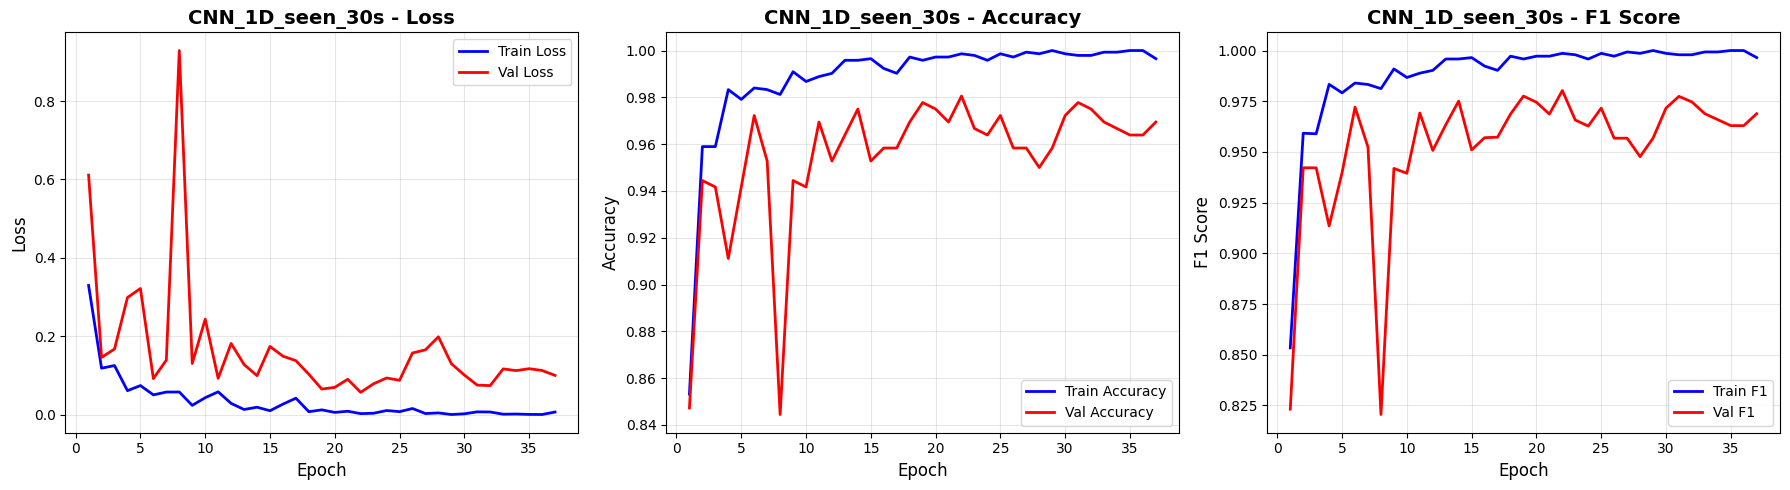


FINAL TEST SET RESULTS
Accuracy:  0.9806
Precision: 0.9943
Recall:    0.9667
F1-Score:  0.9803



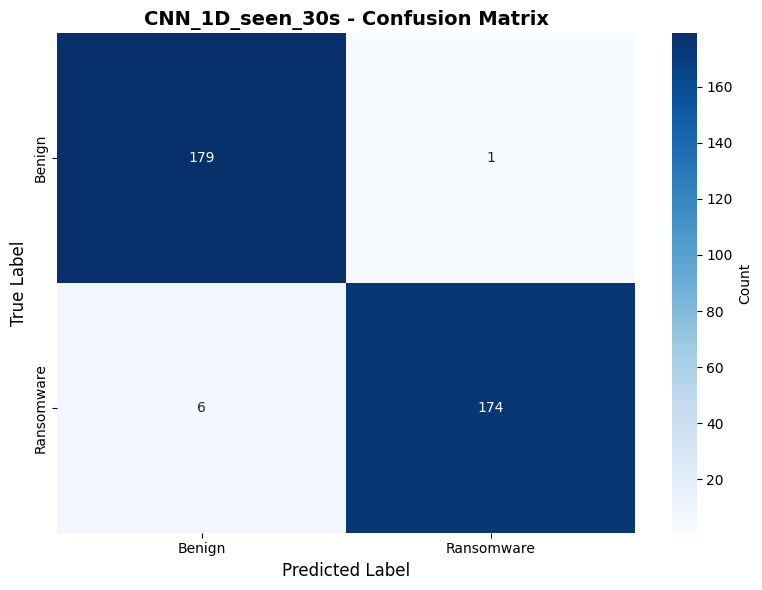


CNN_1D_seen_30s Confusion Matrix:
True Negatives (Benign correctly identified): 179
False Positives (Benign misclassified as Ransomware): 1
False Negatives (Ransomware misclassified as Benign): 6
True Positives (Ransomware correctly identified): 174


In [392]:
CNN_1D_model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
CNN_1D_seen_30s_trained_model, CNN_1D_seen_30s_history, CNN_1D_seen_30s_test_metrics, CNN_1D_seen_30s_test_preds, CNN_1D_seen_30s_test_labels = train_and_evaluate(CNN_1D_model, train_dataloader_seen_30s, test_dataloader_seen_30s, 'CNN_1D_seen_30s', epochs=100,)


TRAINING CNN_1D_seen_60s
Device: cuda
Total parameters: 248,577
Trainable parameters: 248,577
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.2547 | Train F1: 0.8789 | Val Loss: 0.4153 | Val F1: 0.9302 | Val Acc: 0.9333
Epoch   2/100 | Train Loss: 0.0875 | Train F1: 0.9743 | Val Loss: 0.4212 | Val F1: 0.9191 | Val Acc: 0.9139
Epoch   3/100 | Train Loss: 0.0502 | Train F1: 0.9854 | Val Loss: 0.2868 | Val F1: 0.9642 | Val Acc: 0.9639
Epoch   4/100 | Train Loss: 0.0408 | Train F1: 0.9874 | Val Loss: 1.3737 | Val F1: 0.8451 | Val Acc: 0.8167
Epoch   5/100 | Train Loss: 0.0461 | Train F1: 0.9861 | Val Loss: 0.3076 | Val F1: 0.9140 | Val Acc: 0.9111
Epoch   6/100 | Train Loss: 0.0290 | Train F1: 0.9881 | Val Loss: 0.3577 | Val F1: 0.9434 | Val Acc: 0.9417
Epoch   7/100 | Train Loss: 0.0393 | Train F1: 0.9910 | Val Loss: 0.3009 | Val F1: 0.9665 | Val Acc: 0.9667
Epoch   8/100 | Train Loss: 0.0166 | Train F1: 0.9917 | Val Loss: 0.3447 | Val F1: 0.9835 | Val Acc: 0.9833
Epoch   9/100 | Tra

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

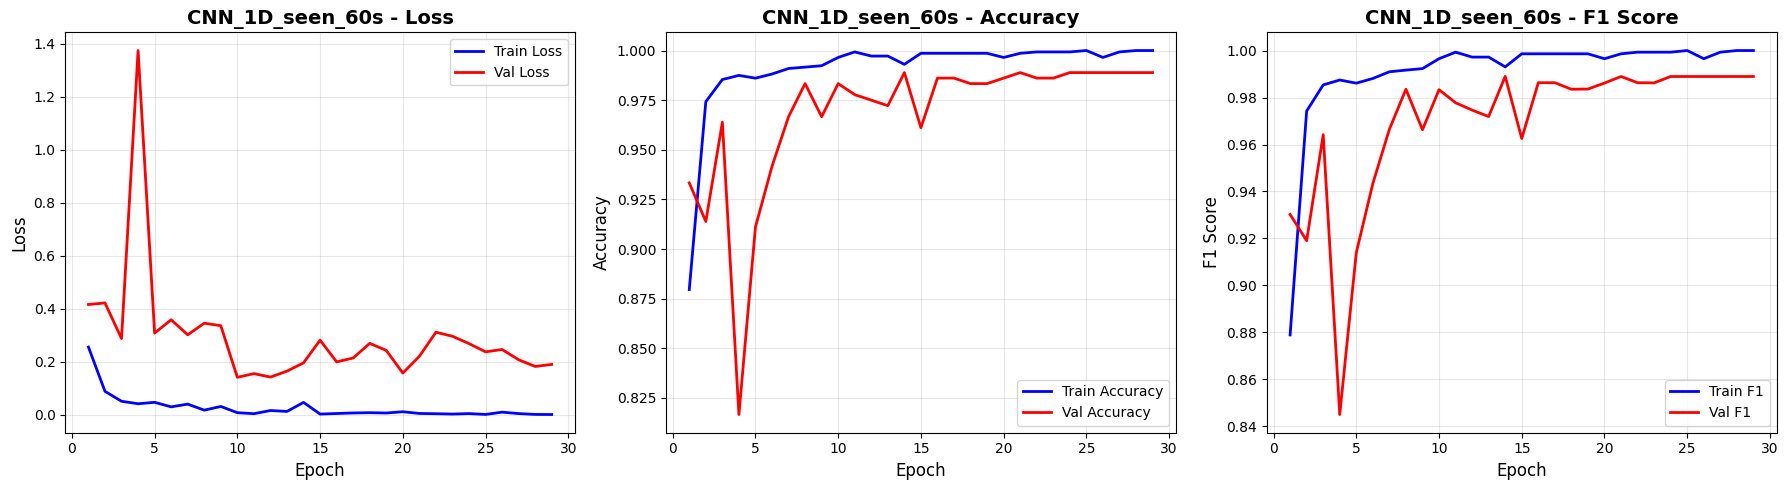


FINAL TEST SET RESULTS
Accuracy:  0.9889
Precision: 0.9783
Recall:    1.0000
F1-Score:  0.9890



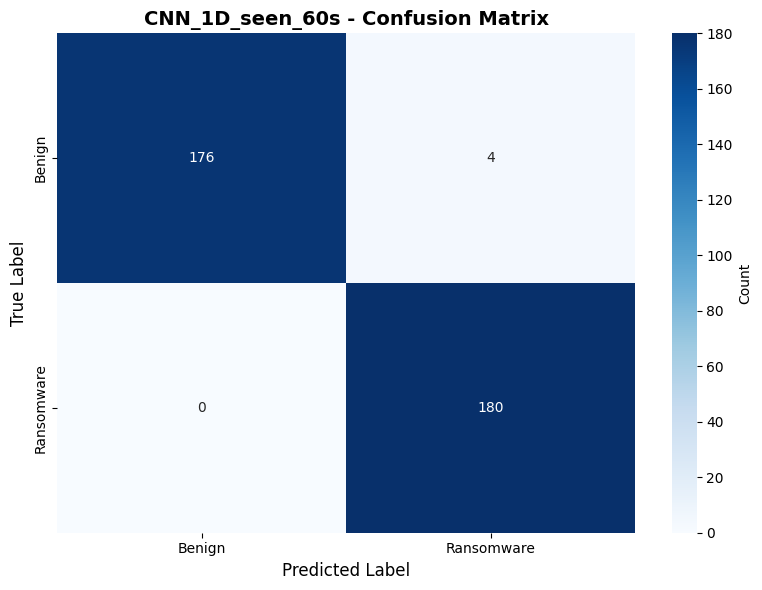


CNN_1D_seen_60s Confusion Matrix:
True Negatives (Benign correctly identified): 176
False Positives (Benign misclassified as Ransomware): 4
False Negatives (Ransomware misclassified as Benign): 0
True Positives (Ransomware correctly identified): 180


In [400]:
CNN_1D_model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
CNN_1D_seen_60s_trained_model, CNN_1D_seen_60s_history, CNN_1D_seen_60s_test_metrics, CNN_1D_seen_60s_test_preds, CNN_1D_seen_60s_test_labels = train_and_evaluate(CNN_1D_model, train_dataloader_seen_60s, test_dataloader_seen_60s, 'CNN_1D_seen_60s', epochs=100,)

In [ ]:
CNN_1D_seen_10s_test_metrics, CNN_1D_seen_20s_test_metrics, CNN_1D_seen_30s_test_metrics, CNN_1D_seen_60s_test_metrics

({'loss': 0.25843657584577473,
  'accuracy': 0.9472222222222222,
  'precision': 0.9214659685863874,
  'recall': 0.9777777777777777,
  'f1': 0.9487870619946092},
 {'loss': 0.1044439496067555,
  'accuracy': 0.9777777777777777,
  'precision': 0.9777777777777777,
  'recall': 0.9777777777777777,
  'f1': 0.9777777777777777},
 {'loss': 0.057046924605637137,
  'accuracy': 0.9805555555555555,
  'precision': 0.9942857142857143,
  'recall': 0.9666666666666667,
  'f1': 0.9802816901408451})

In [403]:
seen_Td = [10, 20, 30, 60]
CNN_1D_results = (CNN_1D_seen_10s_test_metrics, CNN_1D_seen_20s_test_metrics, CNN_1D_seen_30s_test_metrics, CNN_1D_seen_60s_test_metrics)
CNN_1D_seen_losses = [d['loss'] for d in CNN_1D_results]
CNN_1D_seen_acc = [d['accuracy'] for d in CNN_1D_results]
CNN_1D_seen_f1 = [d['f1'] for d in CNN_1D_results]
CNN_1D_seen_recall = [d['recall'] for d in CNN_1D_results]

In [397]:
def plot_metric(x, y, metric_name):
    plt.figure(figsize=(6,4))
    plt.plot(x, y, marker='o', linestyle='-')
    plt.xlabel('Timestamp')
    plt.ylabel(metric_name.capitalize())
    plt.title(f'{metric_name.capitalize()} over Time')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

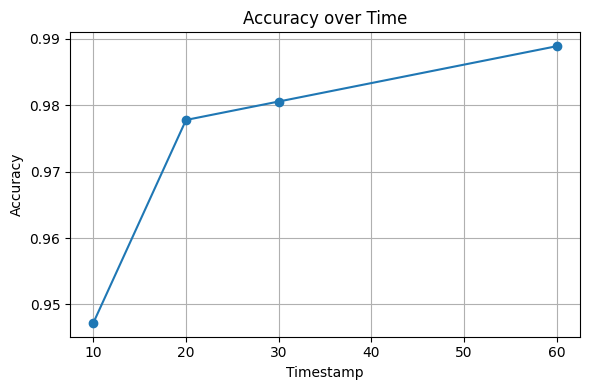

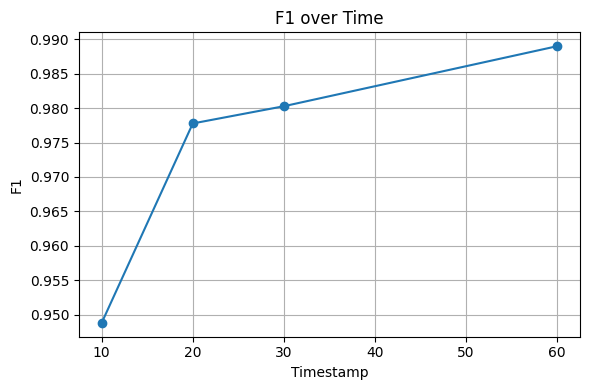

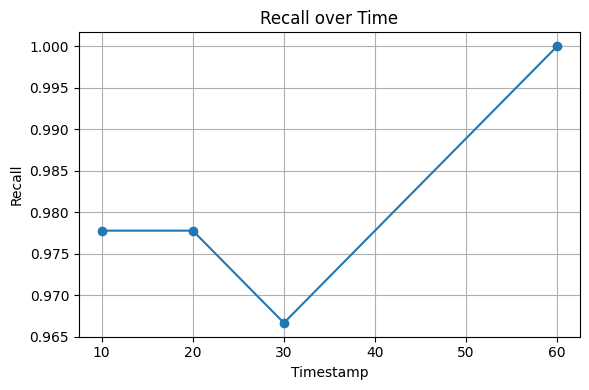

In [405]:
# plot_metric(seen_Td, CNN_1D_seen_losses, 'loss')
plot_metric(seen_Td, CNN_1D_seen_acc, 'accuracy')
plot_metric(seen_Td, CNN_1D_seen_f1, 'f1')
plot_metric(seen_Td, CNN_1D_seen_recall, 'recall')

#### Simple LSTM


TRAINING simpleLSTM_seen_10s
Device: cuda
Total parameters: 39,745
Trainable parameters: 39,745
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.5299 | Train F1: 0.7724 | Val Loss: 0.3187 | Val F1: 0.8647 | Val Acc: 0.8722
Epoch   2/100 | Train Loss: 0.2225 | Train F1: 0.9198 | Val Loss: 0.2247 | Val F1: 0.9029 | Val Acc: 0.9056
Epoch   3/100 | Train Loss: 0.1530 | Train F1: 0.9543 | Val Loss: 0.2123 | Val F1: 0.9202 | Val Acc: 0.9167
Epoch   4/100 | Train Loss: 0.1175 | Train F1: 0.9636 | Val Loss: 0.4099 | Val F1: 0.8313 | Val Acc: 0.8500
Epoch   5/100 | Train Loss: 0.0960 | Train F1: 0.9731 | Val Loss: 0.2889 | Val F1: 0.9017 | Val Acc: 0.9056
Epoch   6/100 | Train Loss: 0.0601 | Train F1: 0.9819 | Val Loss: 0.3000 | Val F1: 0.8968 | Val Acc: 0.9028
Epoch   7/100 | Train Loss: 0.0633 | Train F1: 0.9827 | Val Loss: 0.2245 | Val F1: 0.9282 | Val Acc: 0.9278
Epoch   8/100 | Train Loss: 0.0465 | Train F1: 0.9875 | Val Loss: 0.3221 | Val F1: 0.9006 | Val Acc: 0.9056
Epoch   9/100 | T

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

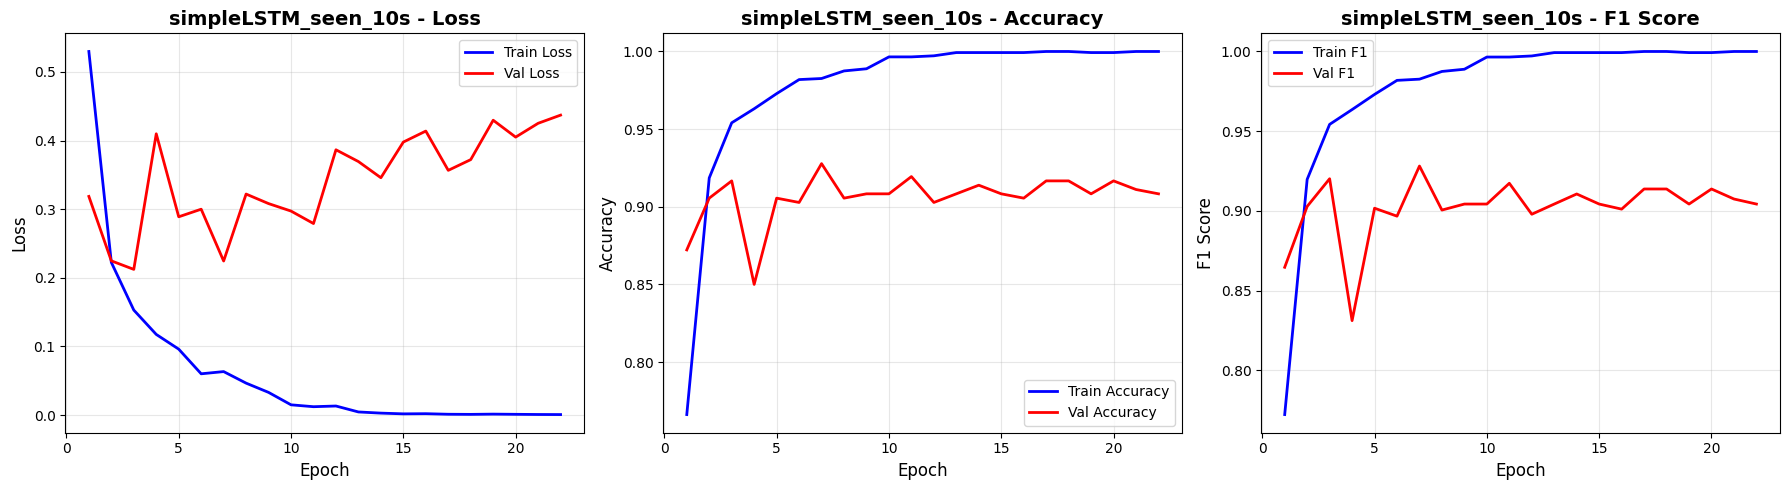


FINAL TEST SET RESULTS
Accuracy:  0.9278
Precision: 0.9231
Recall:    0.9333
F1-Score:  0.9282



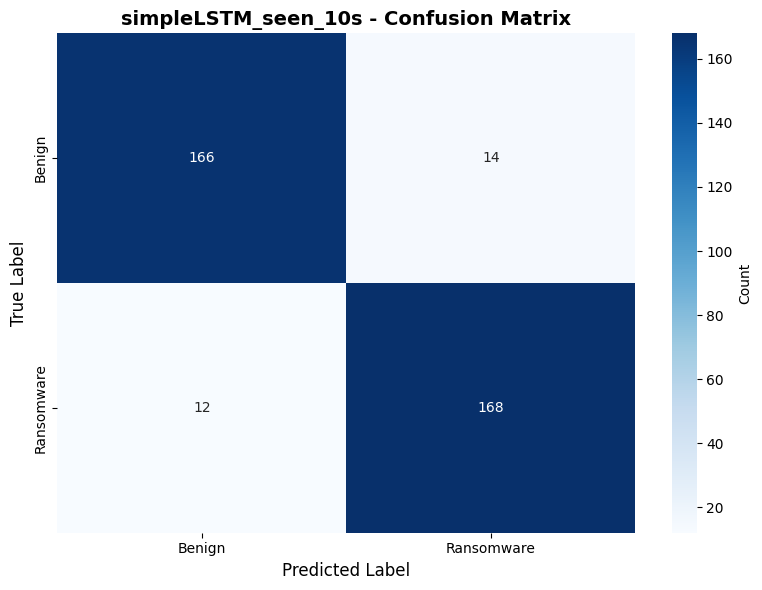


simpleLSTM_seen_10s Confusion Matrix:
True Negatives (Benign correctly identified): 166
False Positives (Benign misclassified as Ransomware): 14
False Negatives (Ransomware misclassified as Benign): 12
True Positives (Ransomware correctly identified): 168

TRAINING simpleLSTM_seen_20s
Device: cuda
Total parameters: 39,745
Trainable parameters: 39,745
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.5101 | Train F1: 0.7957 | Val Loss: 0.3653 | Val F1: 0.8411 | Val Acc: 0.8583
Epoch   2/100 | Train Loss: 0.1368 | Train F1: 0.9628 | Val Loss: 0.2180 | Val F1: 0.9153 | Val Acc: 0.9167
Epoch   3/100 | Train Loss: 0.0697 | Train F1: 0.9827 | Val Loss: 0.3338 | Val F1: 0.8889 | Val Acc: 0.8972
Epoch   4/100 | Train Loss: 0.0474 | Train F1: 0.9889 | Val Loss: 0.2915 | Val F1: 0.9159 | Val Acc: 0.9194
Epoch   5/100 | Train Loss: 0.0371 | Train F1: 0.9903 | Val Loss: 0.3740 | Val F1: 0.8982 | Val Acc: 0.9056
Epoch   6/100 | Train Loss: 0.0198 | Train F1: 0.9958 | Val Loss: 0.3603 | Val F1: 0

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

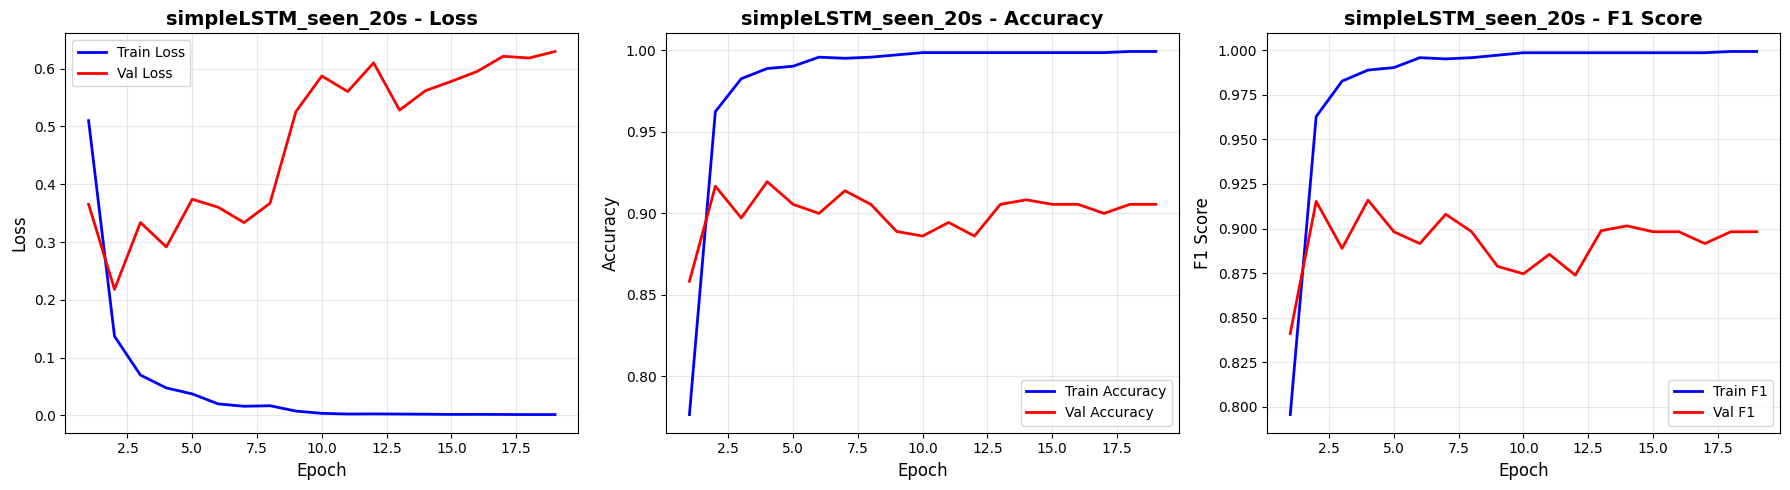


FINAL TEST SET RESULTS
Accuracy:  0.9194
Precision: 0.9576
Recall:    0.8778
F1-Score:  0.9159



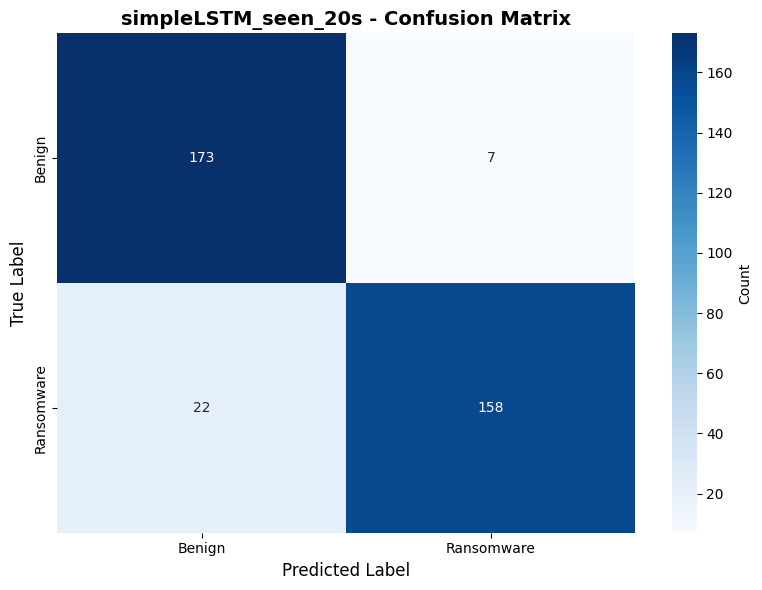


simpleLSTM_seen_20s Confusion Matrix:
True Negatives (Benign correctly identified): 173
False Positives (Benign misclassified as Ransomware): 7
False Negatives (Ransomware misclassified as Benign): 22
True Positives (Ransomware correctly identified): 158

TRAINING simpleLSTM_seen_30s
Device: cuda
Total parameters: 39,745
Trainable parameters: 39,745
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.4595 | Train F1: 0.8072 | Val Loss: 0.3251 | Val F1: 0.8389 | Val Acc: 0.8528
Epoch   2/100 | Train Loss: 0.0916 | Train F1: 0.9755 | Val Loss: 0.1909 | Val F1: 0.9248 | Val Acc: 0.9250
Epoch   3/100 | Train Loss: 0.0416 | Train F1: 0.9888 | Val Loss: 0.2357 | Val F1: 0.8971 | Val Acc: 0.9000
Epoch   4/100 | Train Loss: 0.0179 | Train F1: 0.9937 | Val Loss: 0.2616 | Val F1: 0.9138 | Val Acc: 0.9167
Epoch   5/100 | Train Loss: 0.0124 | Train F1: 0.9979 | Val Loss: 0.2451 | Val F1: 0.9244 | Val Acc: 0.9250
Epoch   6/100 | Train Loss: 0.0019 | Train F1: 1.0000 | Val Loss: 0.3739 | Val F1: 0.

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

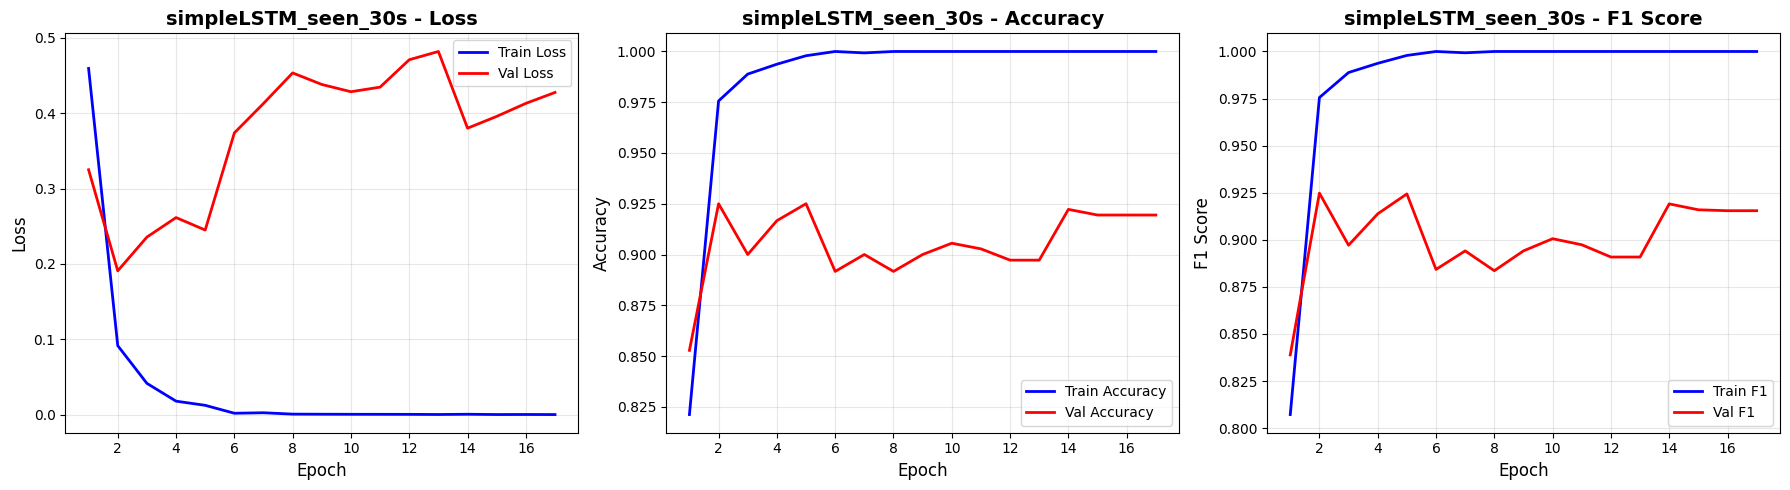


FINAL TEST SET RESULTS
Accuracy:  0.9250
Precision: 0.9274
Recall:    0.9222
F1-Score:  0.9248



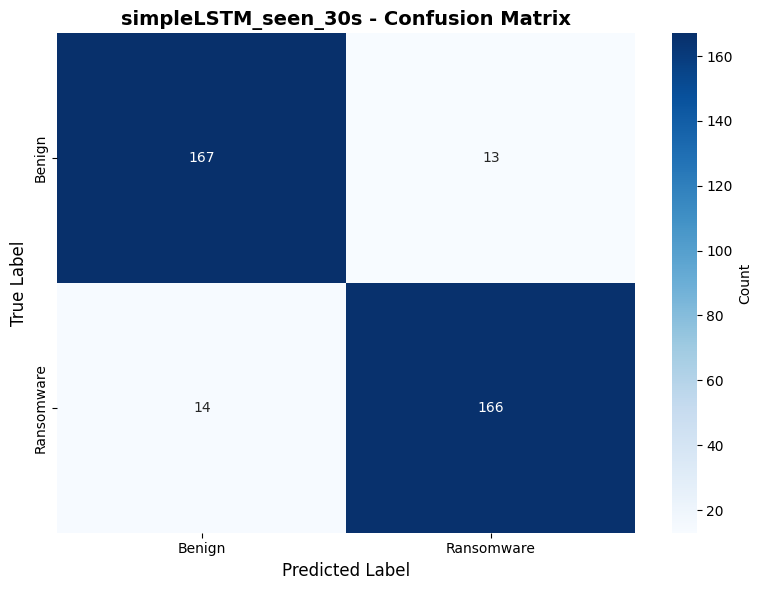


simpleLSTM_seen_30s Confusion Matrix:
True Negatives (Benign correctly identified): 167
False Positives (Benign misclassified as Ransomware): 13
False Negatives (Ransomware misclassified as Benign): 14
True Positives (Ransomware correctly identified): 166

TRAINING simpleLSTM_seen_60s
Device: cuda
Total parameters: 39,745
Trainable parameters: 39,745
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.4433 | Train F1: 0.8487 | Val Loss: 0.2334 | Val F1: 0.9189 | Val Acc: 0.9167
Epoch   2/100 | Train Loss: 0.0609 | Train F1: 0.9854 | Val Loss: 0.1517 | Val F1: 0.9526 | Val Acc: 0.9528
Epoch   3/100 | Train Loss: 0.0323 | Train F1: 0.9910 | Val Loss: 0.0971 | Val F1: 0.9775 | Val Acc: 0.9778
Epoch   4/100 | Train Loss: 0.0071 | Train F1: 0.9986 | Val Loss: 0.0835 | Val F1: 0.9805 | Val Acc: 0.9806
Epoch   5/100 | Train Loss: 0.0066 | Train F1: 0.9986 | Val Loss: 0.1686 | Val F1: 0.9573 | Val Acc: 0.9583
Epoch   6/100 | Train Loss: 0.0020 | Train F1: 0.9993 | Val Loss: 0.1046 | Val F1: 0

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

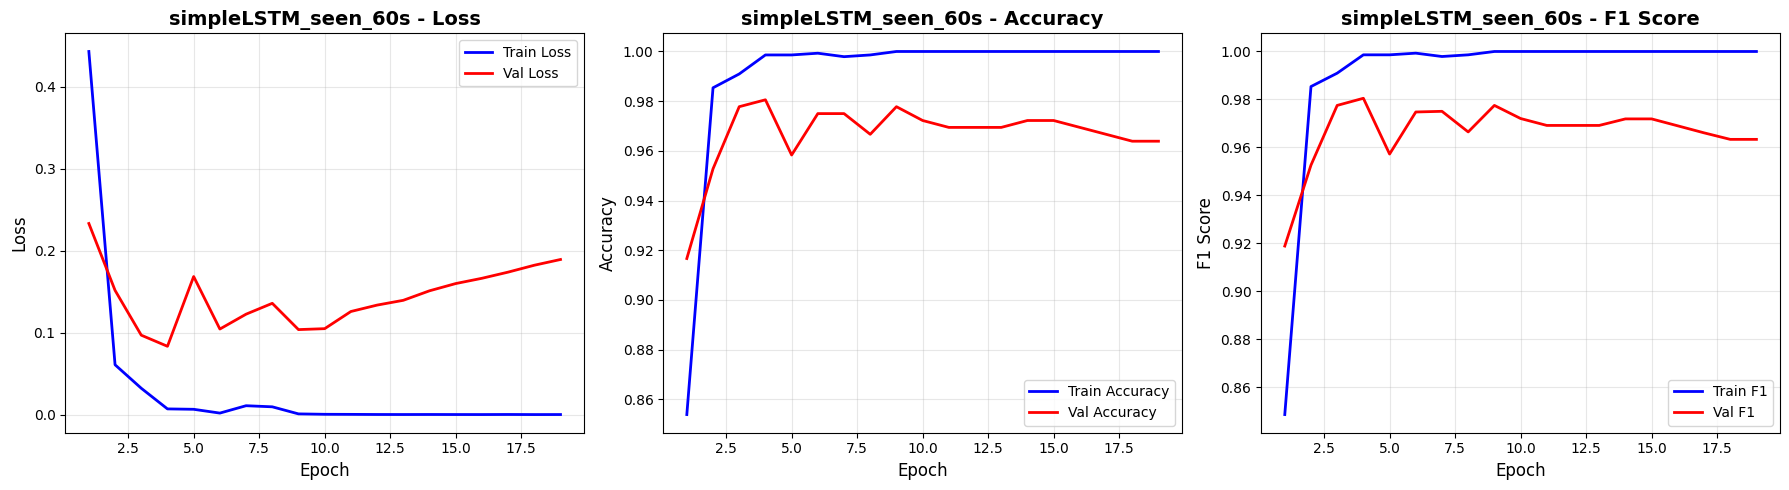


FINAL TEST SET RESULTS
Accuracy:  0.9806
Precision: 0.9832
Recall:    0.9778
F1-Score:  0.9805



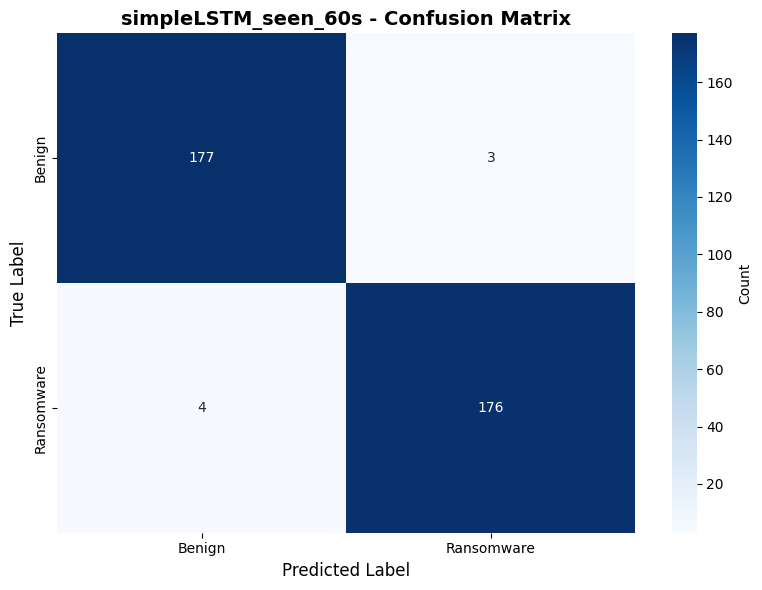


simpleLSTM_seen_60s Confusion Matrix:
True Negatives (Benign correctly identified): 177
False Positives (Benign misclassified as Ransomware): 3
False Negatives (Ransomware misclassified as Benign): 4
True Positives (Ransomware correctly identified): 176


In [411]:
simpleLSTM_model = SimpleLSTM(input_size=len(feature_cols))
simpleLSTM_seen_10s_trained_model, simpleLSTM_seen_10s_history, simpleLSTM_seen_10s_test_metrics, simpleLSTM_seen_10s_test_preds, simpleLSTM_seen_10s_test_labels = train_and_evaluate(simpleLSTM_model, train_dataloader_seen_10s, test_dataloader_seen_10s, 'simpleLSTM_seen_10s', epochs=100,)

simpleLSTM_model = SimpleLSTM(input_size=len(feature_cols))
simpleLSTM_seen_20s_trained_model, simpleLSTM_seen_20s_history, simpleLSTM_seen_20s_test_metrics, simpleLSTM_seen_20s_test_preds, simpleLSTM_seen_20s_test_labels = train_and_evaluate(simpleLSTM_model, train_dataloader_seen_20s, test_dataloader_seen_20s, 'simpleLSTM_seen_20s', epochs=100,)

simpleLSTM_model = SimpleLSTM(input_size=len(feature_cols))
simpleLSTM_seen_30s_trained_model, simpleLSTM_seen_30s_history, simpleLSTM_seen_30s_test_metrics, simpleLSTM_seen_30s_test_preds, simpleLSTM_seen_30s_test_labels = train_and_evaluate(simpleLSTM_model, train_dataloader_seen_30s, test_dataloader_seen_30s, 'simpleLSTM_seen_30s', epochs=100,)

simpleLSTM_model = SimpleLSTM(input_size=len(feature_cols))
simpleLSTM_seen_60s_trained_model, simpleLSTM_seen_60s_history, simpleLSTM_seen_60s_test_metrics, simpleLSTM_seen_60s_test_preds, simpleLSTM_seen_60s_test_labels = train_and_evaluate(simpleLSTM_model, train_dataloader_seen_60s, test_dataloader_seen_60s, 'simpleLSTM_seen_60s', epochs=100,)


TRAINING simpleLSTM_seen_180s
Device: cuda
Total parameters: 55,793
Trainable parameters: 55,793
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.3927 | Train F1: 0.8501 | Val Loss: 0.0658 | Val F1: 0.9831 | Val Acc: 0.9833
Epoch   2/100 | Train Loss: 0.0991 | Train F1: 0.9719 | Val Loss: 0.1047 | Val F1: 0.9783 | Val Acc: 0.9778
Epoch   3/100 | Train Loss: 0.0272 | Train F1: 0.9951 | Val Loss: 0.2369 | Val F1: 0.9600 | Val Acc: 0.9583
Epoch   4/100 | Train Loss: 0.0120 | Train F1: 0.9986 | Val Loss: 0.0870 | Val F1: 0.9781 | Val Acc: 0.9778
Epoch   5/100 | Train Loss: 0.0080 | Train F1: 0.9986 | Val Loss: 0.0702 | Val F1: 0.9806 | Val Acc: 0.9806
Epoch   6/100 | Train Loss: 0.0214 | Train F1: 0.9972 | Val Loss: 0.1706 | Val F1: 0.9677 | Val Acc: 0.9667
Epoch   7/100 | Train Loss: 0.0088 | Train F1: 0.9986 | Val Loss: 0.0915 | Val F1: 0.9781 | Val Acc: 0.9778
Epoch   8/100 | Train Loss: 0.0067 | Train F1: 0.9986 | Val Loss: 0.1170 | Val F1: 0.9752 | Val Acc: 0.9750
Epoch   9/100 | 

C:\Users\malio\AppData\Local\Temp\ipykernel_91524\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

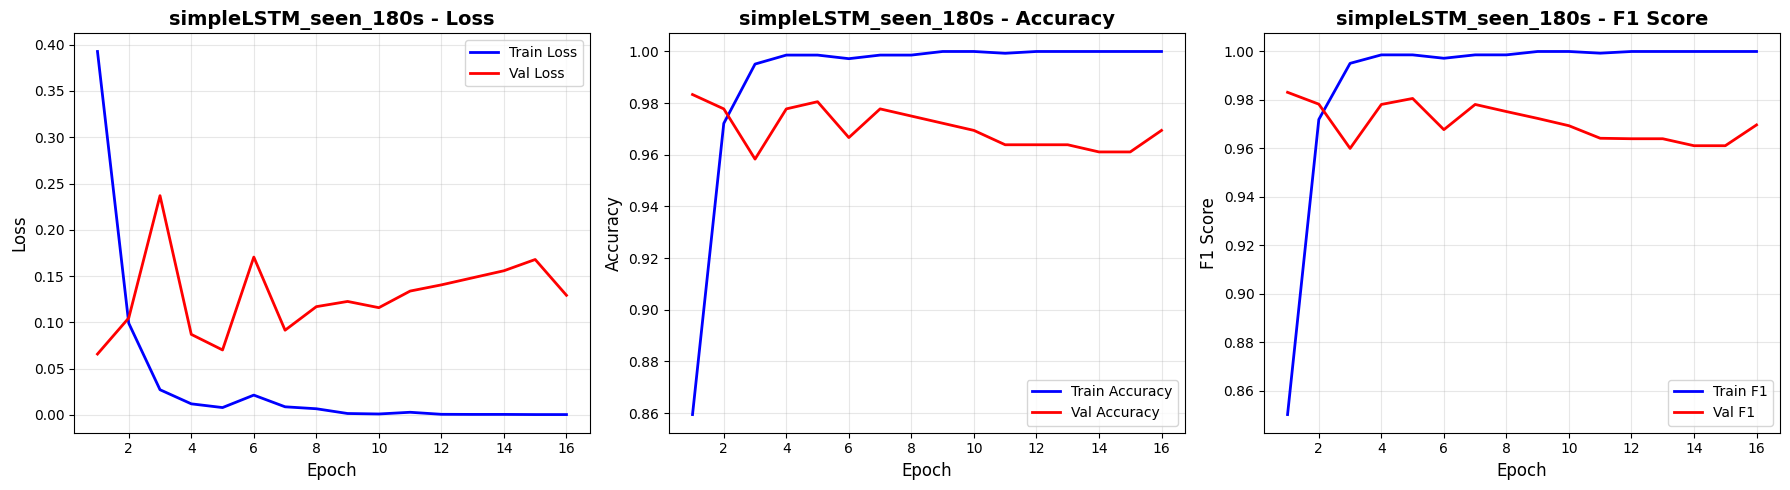


FINAL TEST SET RESULTS
Accuracy:  0.9833
Precision: 0.9943
Recall:    0.9722
F1-Score:  0.9831



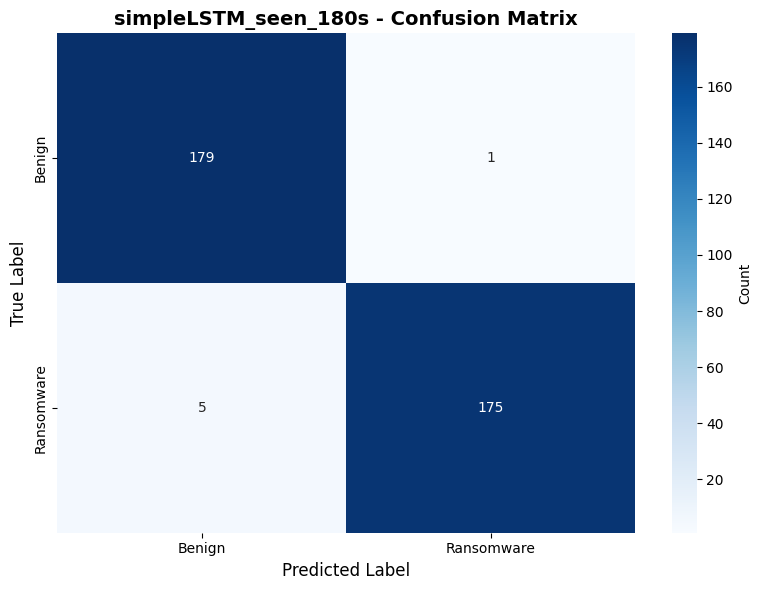


simpleLSTM_seen_180s Confusion Matrix:
True Negatives (Benign correctly identified): 179
False Positives (Benign misclassified as Ransomware): 1
False Negatives (Ransomware misclassified as Benign): 5
True Positives (Ransomware correctly identified): 175


In [29]:
simpleLSTM_model = SimpleLSTM(input_size=len(feature_cols), hidden_size=81)
simpleLSTM_seen_180s_trained_model, simpleLSTM_seen_180s_history, simpleLSTM_seen_180s_test_metrics, simpleLSTM_seen_180s_test_preds, simpleLSTM_seen_180s_test_labels = train_and_evaluate(simpleLSTM_model, train_dataloader_seen_180s, test_dataloader_seen_180s, 'simpleLSTM_seen_180s', epochs=100,)

### Model Analysis

In [422]:
seen_Td = [10, 20, 30, 60]
CNN_1D_results = (CNN_1D_seen_10s_test_metrics, CNN_1D_seen_20s_test_metrics, CNN_1D_seen_30s_test_metrics, CNN_1D_seen_60s_test_metrics)
CNN_1D_seen_losses = [d['loss'] for d in CNN_1D_results]
CNN_1D_seen_acc = [d['accuracy'] for d in CNN_1D_results]
CNN_1D_seen_f1 = [d['f1'] for d in CNN_1D_results]
CNN_1D_seen_recall = [d['recall'] for d in CNN_1D_results]

simpleLSTM_results = (simpleLSTM_seen_10s_test_metrics, simpleLSTM_seen_20s_test_metrics, simpleLSTM_seen_30s_test_metrics, simpleLSTM_seen_60s_test_metrics)
simpleLSTM_seen_losses = [d['loss'] for d in simpleLSTM_results]
simpleLSTM_seen_acc = [d['accuracy'] for d in simpleLSTM_results]
simpleLSTM_seen_f1 = [d['f1'] for d in simpleLSTM_results]
simpleLSTM_seen_recall = [d['recall'] for d in simpleLSTM_results]


seen_losses = {'CNN_1D': CNN_1D_seen_losses, 'LSTM': simpleLSTM_seen_losses}
seen_acc = {'CNN_1D': CNN_1D_seen_acc, 'LSTM': simpleLSTM_seen_acc}
seen_f1 = {'CNN_1D': CNN_1D_seen_f1, 'LSTM': simpleLSTM_seen_f1}
seen_recall = {'CNN_1D': CNN_1D_seen_recall, 'LSTM': simpleLSTM_seen_recall}

In [ ]:
def plot_metric(x, models_and_results, metric_name):
    plt.figure(figsize=(6,4))
    for model_name, results in models_and_results.items():
        plt.plot(x, results, marker='o', linestyle='-', label=model_name)

    plt.xlabel('Total sequence time (Td) (s)')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} over Time')
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()


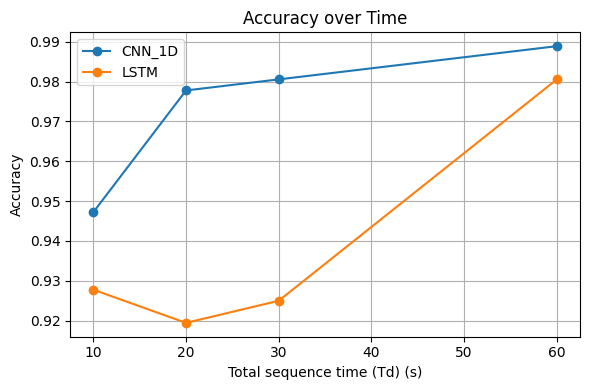

In [ ]:
plot_metric(seen_Td, seen_acc, 'Accuracy')

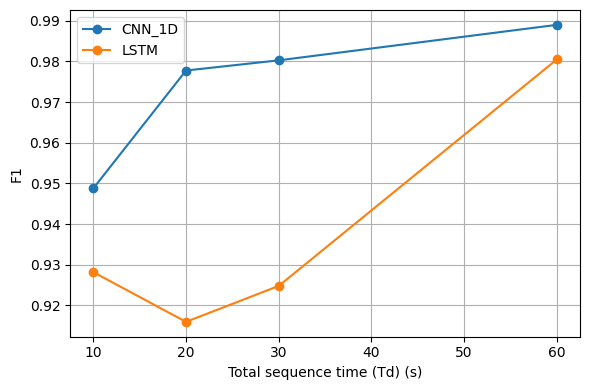

In [ ]:
plot_metric(seen_Td, seen_f1, 'F1')

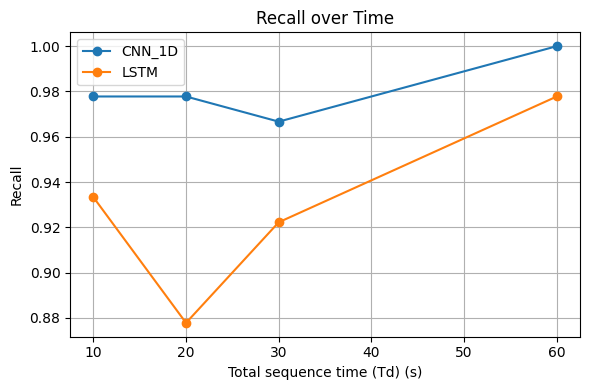

In [ ]:
plot_metric(seen_Td, seen_recall, 'Recall')

## Unseen ransomware

### 1D CNN

In [ ]:
train_dataloader_unseen_180s


TRAINING CNN_1D_unseen_120s
Device: cuda
Total parameters: 248,577
Trainable parameters: 248,577
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.1865 | Train F1: 0.9306 | Val Loss: 2.7667 | Val F1: 0.0000 | Val Acc: 0.4966
Epoch   2/100 | Train Loss: 0.0384 | Train F1: 0.9933 | Val Loss: 1.6101 | Val F1: 0.0238 | Val Acc: 0.4497
Epoch   3/100 | Train Loss: 0.0228 | Train F1: 0.9933 | Val Loss: 3.2464 | Val F1: 0.0000 | Val Acc: 0.5000
Epoch   4/100 | Train Loss: 0.0150 | Train F1: 0.9960 | Val Loss: 2.8219 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   5/100 | Train Loss: 0.0147 | Train F1: 0.9980 | Val Loss: 5.9918 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   6/100 | Train Loss: 0.0254 | Train F1: 0.9927 | Val Loss: 3.8331 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   7/100 | Train Loss: 0.0163 | Train F1: 0.9953 | Val Loss: 6.5861 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   8/100 | Train Loss: 0.0205 | Train F1: 0.9933 | Val Loss: 7.0955 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   9/100 | 

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\1009470381.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

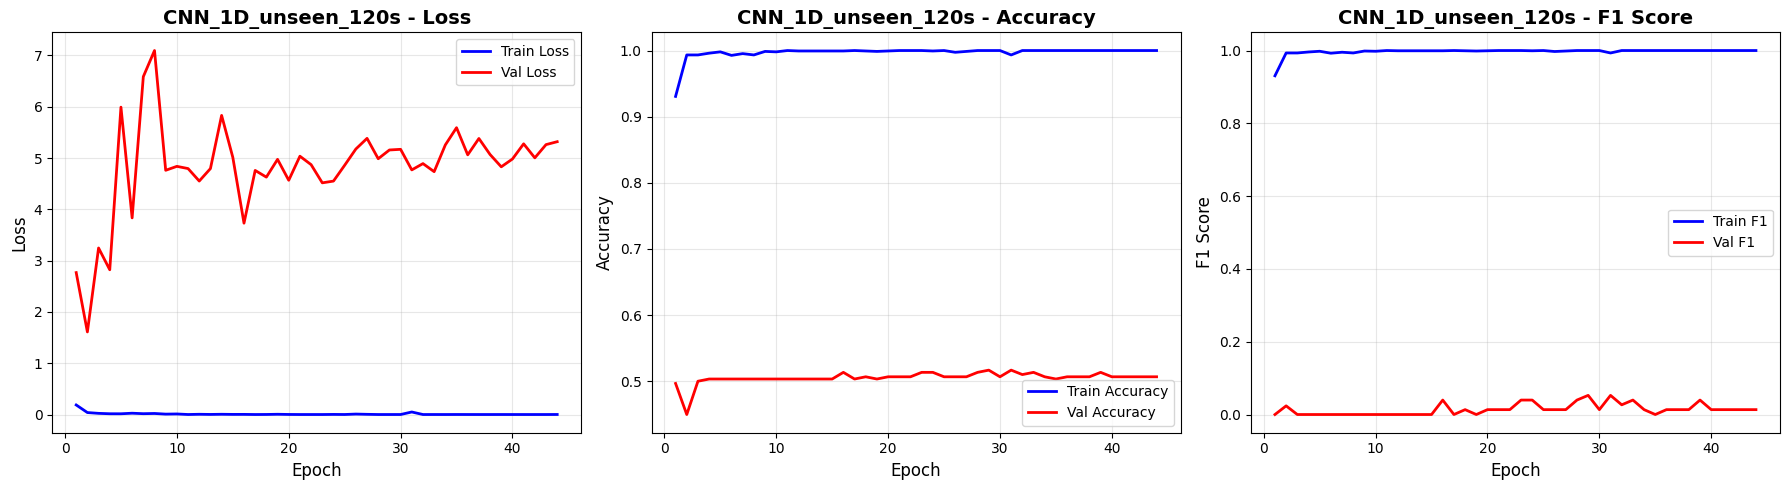


FINAL TEST SET RESULTS
Accuracy:  0.5168
Precision: 1.0000
Recall:    0.0270
F1-Score:  0.0526
AUC:       0.3941



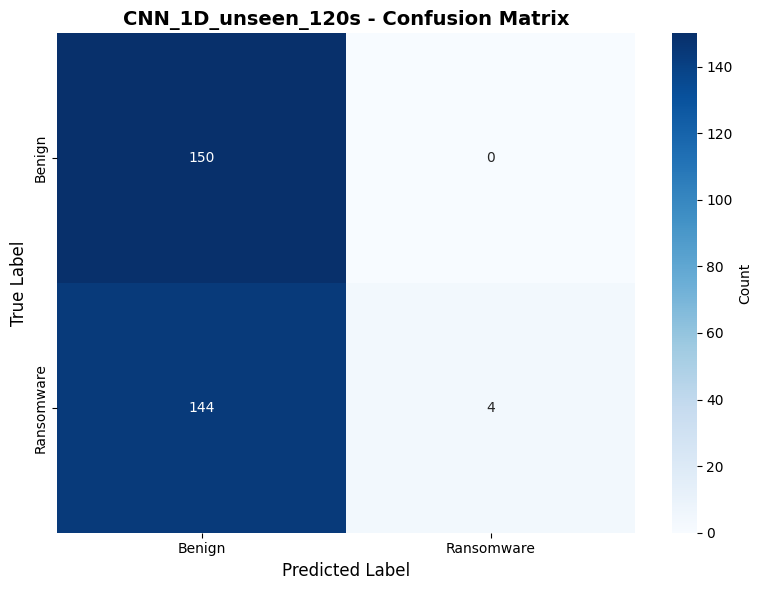


CNN_1D_unseen_120s Confusion Matrix:
True Negatives (Benign correctly identified): 150
False Positives (Benign misclassified as Ransomware): 0
False Negatives (Ransomware misclassified as Benign): 144
True Positives (Ransomware correctly identified): 4


In [ ]:
CNN_1D_model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
CNN_1D_unseen_120s_trained_model, CNN_1D_unseen_120s_history, CNN_1D_unseen_120s_test_metrics, CNN_1D_unseen_120s_test_preds, CNN_1D_unseen_120s_test_labels = train_and_evaluate(CNN_1D_model, train_dataloader_unseen_120s, test_dataloader_unseen_120s, 'CNN_1D_unseen_120s', epochs=100,)

In [ ]:
CNN_1D_model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
CNN_1D_unseen_120s_trained_model, CNN_1D_unseen_120s_history, CNN_1D_unseen_120s_test_metrics, CNN_1D_unseen_120s_test_preds, CNN_1D_unseen_120s_test_labels = train_and_evaluate(CNN_1D_model, train_dataloader_unseen_120s, test_dataloader_unseen_120s, 'CNN_1D_unseen_120s', epochs=100,)


TRAINING CNN_1D_unseen_180s
Device: cuda
Total parameters: 248,577
Trainable parameters: 248,577
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.1749 | Train F1: 0.9241 | Val Loss: 2.1498 | Val F1: 0.0355 | Val Acc: 0.4530
Epoch   2/100 | Train Loss: 0.0301 | Train F1: 0.9940 | Val Loss: 1.6459 | Val F1: 0.0256 | Val Acc: 0.4899
Epoch   3/100 | Train Loss: 0.0100 | Train F1: 0.9987 | Val Loss: 2.5186 | Val F1: 0.0000 | Val Acc: 0.4933
Epoch   4/100 | Train Loss: 0.0152 | Train F1: 0.9973 | Val Loss: 4.0781 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   5/100 | Train Loss: 0.0146 | Train F1: 0.9967 | Val Loss: 3.8934 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   6/100 | Train Loss: 0.0116 | Train F1: 0.9973 | Val Loss: 3.0154 | Val F1: 0.0000 | Val Acc: 0.5000
Epoch   7/100 | Train Loss: 0.0114 | Train F1: 0.9987 | Val Loss: 4.4413 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   8/100 | Train Loss: 0.0086 | Train F1: 0.9967 | Val Loss: 4.4729 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   9/100 | 

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

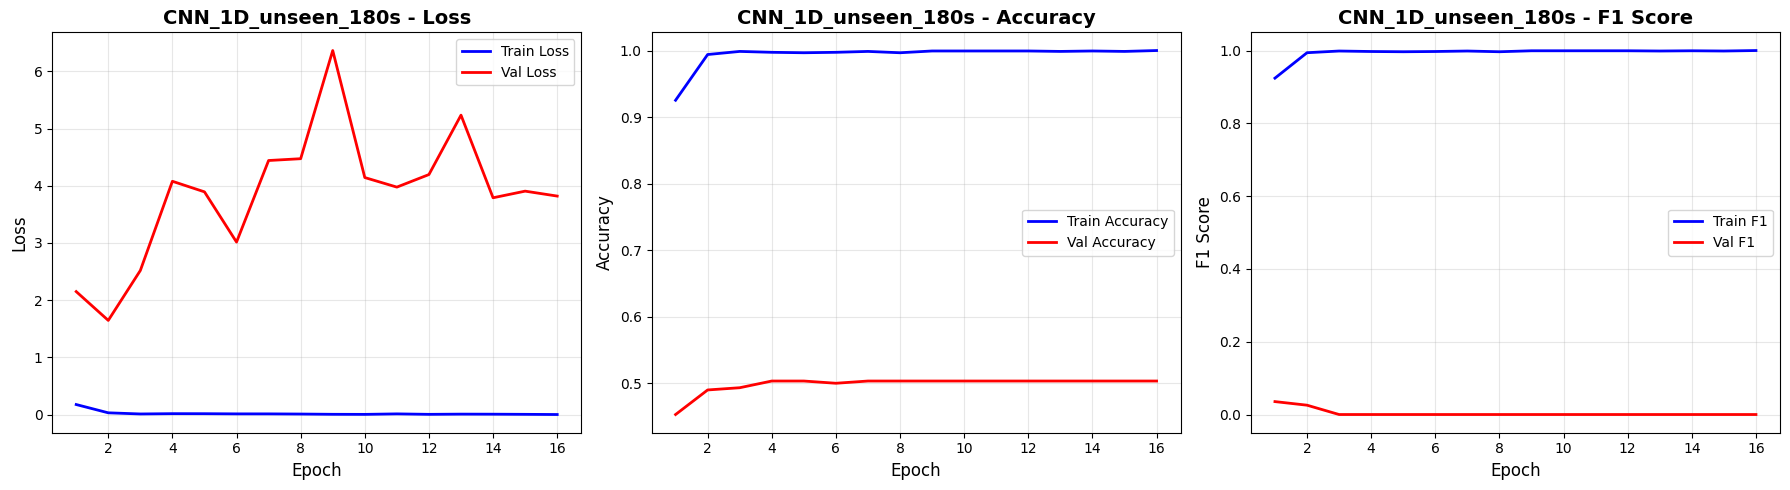


FINAL TEST SET RESULTS
Accuracy:  0.4530
Precision: 0.1429
Recall:    0.0203
F1-Score:  0.0355



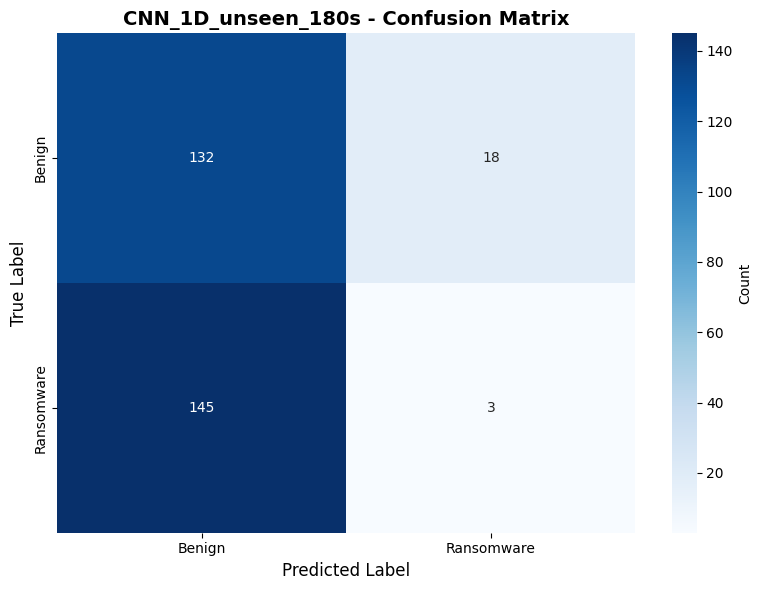


CNN_1D_unseen_180s Confusion Matrix:
True Negatives (Benign correctly identified): 132
False Positives (Benign misclassified as Ransomware): 18
False Negatives (Ransomware misclassified as Benign): 145
True Positives (Ransomware correctly identified): 3


In [437]:
CNN_1D_model = SimpleCNN1D(input_size=len(feature_cols), num_filters=64, dropout=0.3)
CNN_1D_unseen_180s_trained_model, CNN_1D_unseen_180s_history, CNN_1D_unseen_180s_test_metrics, CNN_1D_unseen_180s_test_preds, CNN_1D_unseen_180s_test_labels = train_and_evaluate(CNN_1D_model, train_dataloader_unseen_180s, test_dataloader_unseen_180s, 'CNN_1D_unseen_180s', epochs=100,)

### LSTM


TRAINING simple_LSTM_unseen_120s
Device: cuda
Total parameters: 39,745
Trainable parameters: 39,745
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.6946 | Train F1: 0.1630 | Val Loss: 0.6931 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   2/100 | Train Loss: 0.6959 | Train F1: 0.5261 | Val Loss: 0.6943 | Val F1: 0.6637 | Val Acc: 0.4966
Epoch   3/100 | Train Loss: 0.6938 | Train F1: 0.5407 | Val Loss: 0.6945 | Val F1: 0.6637 | Val Acc: 0.4966
Epoch   4/100 | Train Loss: 0.6955 | Train F1: 0.6222 | Val Loss: 0.6943 | Val F1: 0.6637 | Val Acc: 0.4966
Epoch   5/100 | Train Loss: 0.6934 | Train F1: 0.6073 | Val Loss: 0.6931 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   6/100 | Train Loss: 0.6937 | Train F1: 0.5105 | Val Loss: 0.6936 | Val F1: 0.6637 | Val Acc: 0.4966
Epoch   7/100 | Train Loss: 0.6934 | Train F1: 0.1532 | Val Loss: 0.6930 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   8/100 | Train Loss: 0.6933 | Train F1: 0.0000 | Val Loss: 0.6931 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   9/100

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

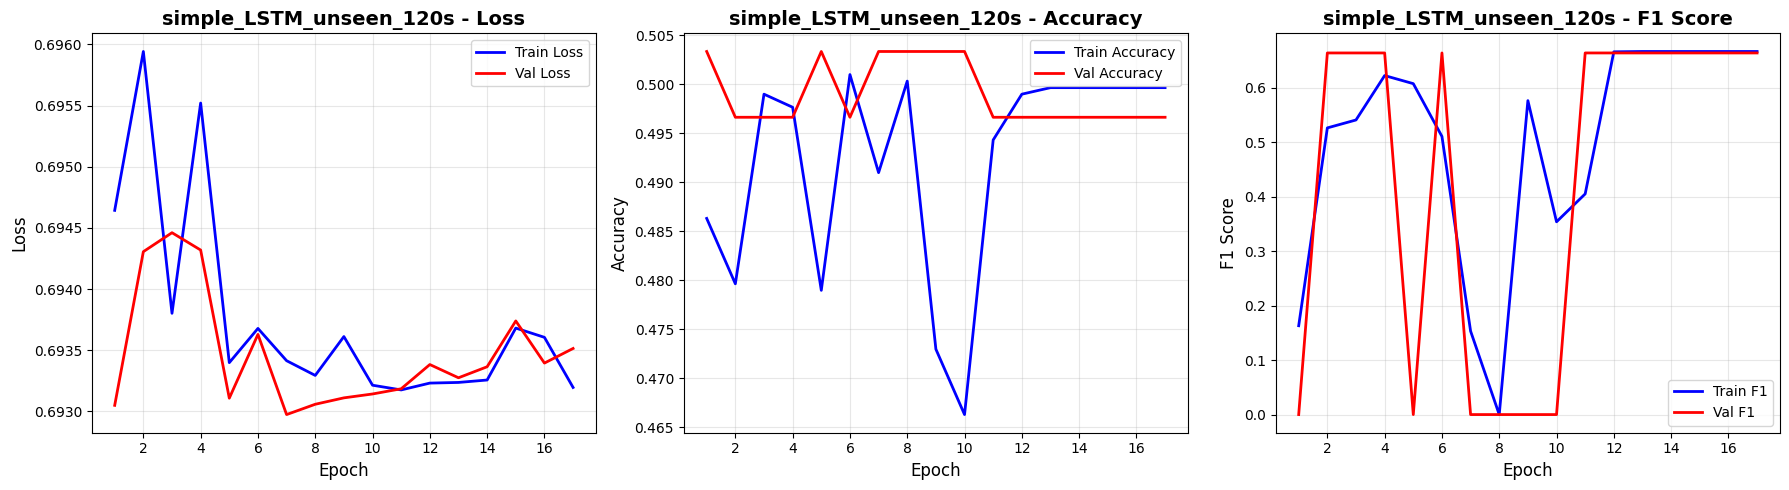


FINAL TEST SET RESULTS
Accuracy:  0.4966
Precision: 0.4966
Recall:    1.0000
F1-Score:  0.6637



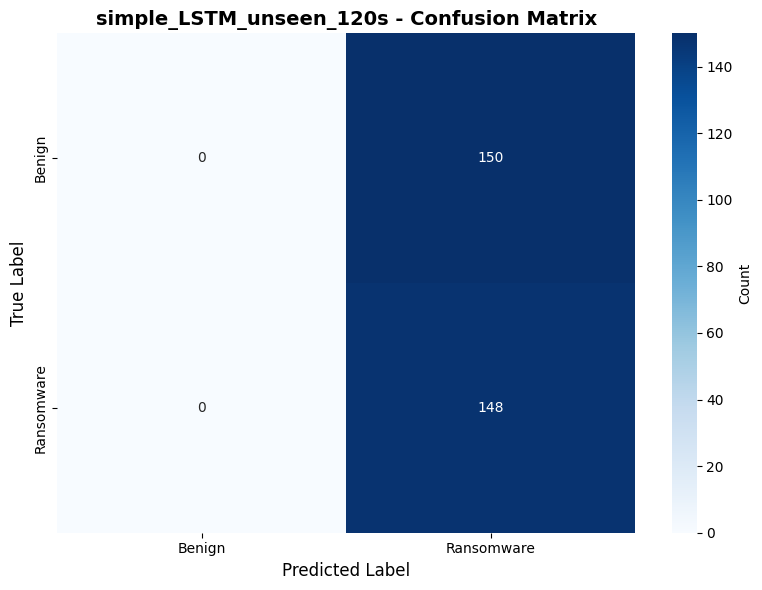


simple_LSTM_unseen_120s Confusion Matrix:
True Negatives (Benign correctly identified): 0
False Positives (Benign misclassified as Ransomware): 150
False Negatives (Ransomware misclassified as Benign): 0
True Positives (Ransomware correctly identified): 148


In [ ]:
simple_lstm = SimpleLSTM(input_size=len(feature_cols), hidden_size=64, num_layers=1, dropout=0.3)
simple_LSTM_unseen_120s_trained_model, simple_LSTM_unseen_120s_history, simple_LSTM_unseen_120s_test_metrics, simple_LSTM_unseen_120s_test_preds, simple_LSTM_unseen_120s_test_labels = train_and_evaluate(simple_lstm, train_dataloader_unseen_120s, test_dataloader_unseen_120s, 'simple_LSTM_unseen_120s', epochs=100,)


TRAINING simple_LSTM_unseen_180s
Device: cuda
Total parameters: 39,745
Trainable parameters: 39,745
Learning rate: 0.001

Epoch   1/100 | Train Loss: 0.4121 | Train F1: 0.8764 | Val Loss: 1.1888 | Val F1: 0.3213 | Val Acc: 0.4329
Epoch   2/100 | Train Loss: 0.0613 | Train F1: 0.9880 | Val Loss: 2.2378 | Val F1: 0.0118 | Val Acc: 0.4362
Epoch   3/100 | Train Loss: 0.0162 | Train F1: 0.9980 | Val Loss: 2.8352 | Val F1: 0.0248 | Val Acc: 0.4732
Epoch   4/100 | Train Loss: 0.0151 | Train F1: 0.9973 | Val Loss: 2.9259 | Val F1: 0.0000 | Val Acc: 0.5034
Epoch   5/100 | Train Loss: 0.0234 | Train F1: 0.9953 | Val Loss: 3.2679 | Val F1: 0.0122 | Val Acc: 0.4564
Epoch   6/100 | Train Loss: 0.0116 | Train F1: 0.9980 | Val Loss: 2.6629 | Val F1: 0.0000 | Val Acc: 0.5000
Epoch   7/100 | Train Loss: 0.0061 | Train F1: 0.9993 | Val Loss: 3.2527 | Val F1: 0.0000 | Val Acc: 0.4966
Epoch   8/100 | Train Loss: 0.0050 | Train F1: 0.9993 | Val Loss: 3.4343 | Val F1: 0.0000 | Val Acc: 0.5000
Epoch   9/100

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2615747900.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_dir, 'best_model

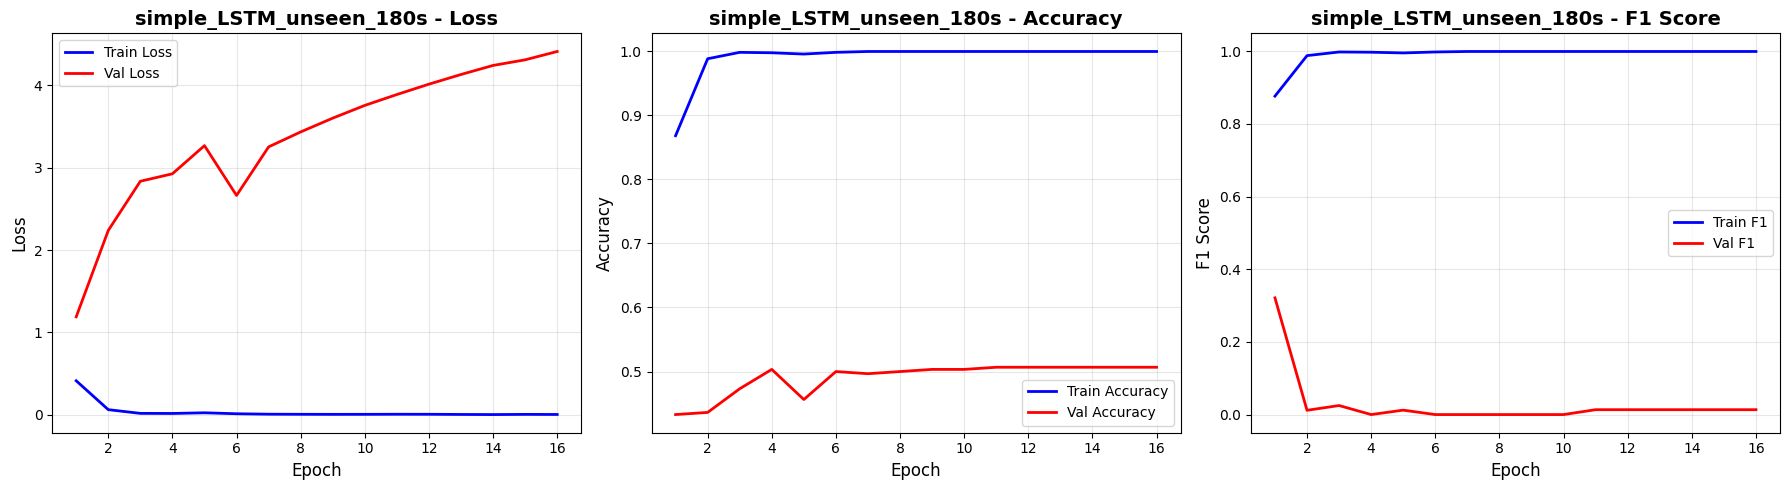


FINAL TEST SET RESULTS
Accuracy:  0.4329
Precision: 0.3960
Recall:    0.2703
F1-Score:  0.3213



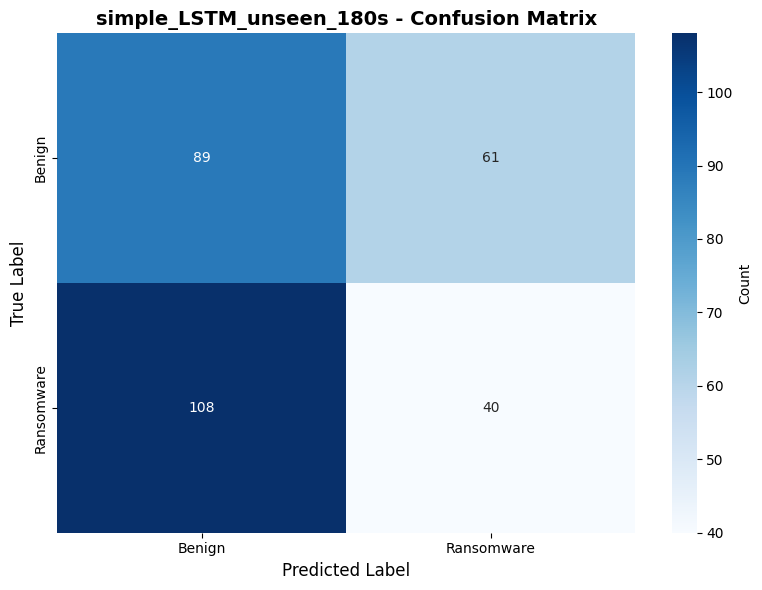


simple_LSTM_unseen_180s Confusion Matrix:
True Negatives (Benign correctly identified): 89
False Positives (Benign misclassified as Ransomware): 61
False Negatives (Ransomware misclassified as Benign): 108
True Positives (Ransomware correctly identified): 40


In [438]:
simple_lstm = SimpleLSTM(input_size=len(feature_cols), hidden_size=64, num_layers=1, dropout=0.3)
simple_LSTM_unseen_180s_trained_model, simple_LSTM_unseen_180s_history, simple_LSTM_unseen_180s_test_metrics, simple_LSTM_unseen_180s_test_preds, simple_LSTM_unseen_180s_test_labels = train_and_evaluate(simple_lstm, train_dataloader_unseen_180s, test_dataloader_unseen_180s, 'simple_LSTM_unseen_180s', epochs=100,)

## Anomaly Detection

In [356]:
lstm_vae = LSTM_VAE(input_size=len(feature_cols))
lstm_vae_10s, lstm_vae_val_reconstruc_losses_10s, lstm_vae_val_kl_losses_10s = train_vae(lstm_vae, train_dataloader_vae_10s, val_dataloader_vae_10s, device='cuda', model_name='lstm_vae_10s')

Epoch 1/50 | Train Loss: 3.1035 | Val Loss: 14.2346 | Recon: 14.2282
Epoch 2/50 | Train Loss: 2.8886 | Val Loss: 13.7951 | Recon: 13.7370
Epoch 3/50 | Train Loss: 2.6750 | Val Loss: 13.6830 | Recon: 13.6221
Epoch 4/50 | Train Loss: 2.6127 | Val Loss: 13.6635 | Recon: 13.6215
Epoch 5/50 | Train Loss: 2.5857 | Val Loss: 13.6695 | Recon: 13.6302
Epoch 6/50 | Train Loss: 2.5622 | Val Loss: 13.6184 | Recon: 13.5900
Epoch 7/50 | Train Loss: 2.5611 | Val Loss: 13.6380 | Recon: 13.6070
Epoch 8/50 | Train Loss: 2.5565 | Val Loss: 13.5877 | Recon: 13.5612
Epoch 9/50 | Train Loss: 2.5418 | Val Loss: 13.6407 | Recon: 13.6189
Epoch 10/50 | Train Loss: 2.5321 | Val Loss: 13.5407 | Recon: 13.5162
Epoch 11/50 | Train Loss: 2.5193 | Val Loss: 13.5243 | Recon: 13.4993
Epoch 12/50 | Train Loss: 2.5060 | Val Loss: 13.5091 | Recon: 13.4700
Epoch 13/50 | Train Loss: 2.4946 | Val Loss: 13.4457 | Recon: 13.3987
Epoch 14/50 | Train Loss: 2.4863 | Val Loss: 13.3992 | Recon: 13.3081
Epoch 15/50 | Train Loss: 2.4

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2101322422.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(save_dir, "v

In [357]:
lstm_vae_test_results_10s = eval_vae(lstm_vae_10s, test_dataloader_vae_10s, device='cuda')
lstm_vae_test_reconstruc_losses_10s = lstm_vae_test_results_10s['reconstruction_losses']

In [358]:
np.max(lstm_vae_val_reconstruc_losses_10s), np.max(lstm_vae_test_reconstruc_losses_10s)

(np.float32(1483.0619), np.float32(172.91519))

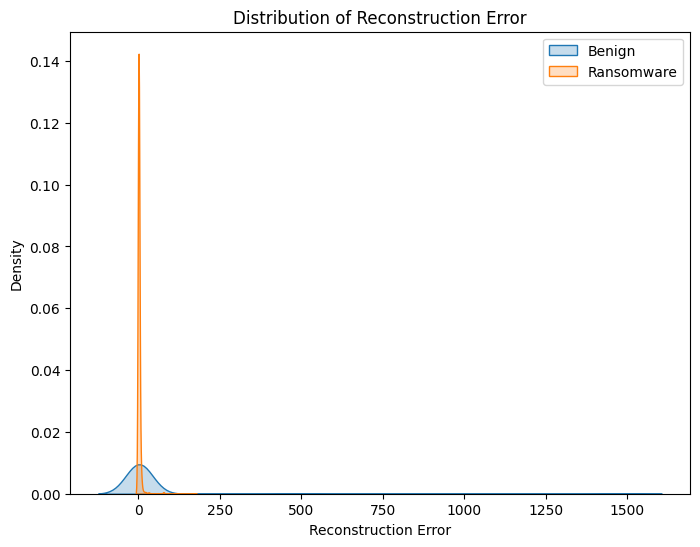

In [359]:
plt.figure(figsize=(8,6))
sns.kdeplot(lstm_vae_val_reconstruc_losses_10s, label="Benign", fill=True)
sns.kdeplot(lstm_vae_test_reconstruc_losses_10s, label="Ransomware", fill=True)
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Distribution of Reconstruction Error")
plt.legend()
plt.show()

In [347]:
def threshold_vae(val_loss, test_loss, error_threshold):
    val_loss_below = [x for x in val_loss if x <= error_threshold]
    test_loss_below = [x for x in test_loss if x<= error_threshold]
    return val_loss_below, test_loss_below
    # [x for x in lstm_vae_test_reconstruc_losses_10s if x < 25]

In [348]:
lstm_vae_val_loss_10s, lstm_vae_test_loss_10s = threshold_vae(best_val_reconstruc_losses_10s, lstm_vae_test_reconstruc_losses_10s, 25)

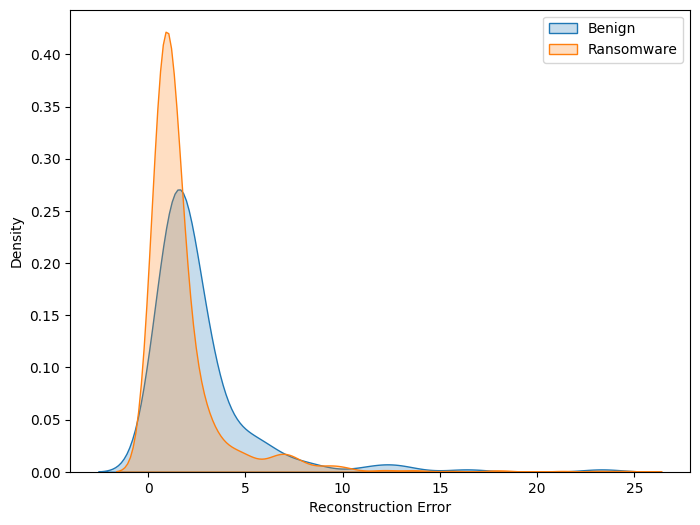

In [434]:
plt.figure(figsize=(8,6))
sns.kdeplot(lstm_vae_val_loss_10s, label="Benign", fill=True)
sns.kdeplot(lstm_vae_test_loss_10s, label="Ransomware", fill=True)
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
# plt.title("Distribution of Reconstruction Error for Benign and")
plt.legend()
plt.show()

In [353]:
lstm_vae = LSTM_VAE(input_size=len(feature_cols))
lstm_vae_180s, lstm_vae_val_reconstruc_losses_180s, lstm_vae_val_kl_losses_180s = train_vae(lstm_vae, train_dataloader_vae_180s, val_dataloader_vae_180s, device='cuda', model_name='lstm_vae_180s')

Epoch 1/50 | Train Loss: 0.9819 | Val Loss: 3.3019 | Recon: 3.3001
Epoch 2/50 | Train Loss: 0.9751 | Val Loss: 3.3007 | Recon: 3.2995
Epoch 3/50 | Train Loss: 0.9617 | Val Loss: 3.2713 | Recon: 3.2700
Epoch 4/50 | Train Loss: 0.9501 | Val Loss: 3.2741 | Recon: 3.2733
Epoch 5/50 | Train Loss: 0.9442 | Val Loss: 3.2434 | Recon: 3.2429
Epoch 6/50 | Train Loss: 0.9366 | Val Loss: 3.2484 | Recon: 3.2480
Epoch 7/50 | Train Loss: 0.9326 | Val Loss: 3.2353 | Recon: 3.2350
Epoch 8/50 | Train Loss: 0.9297 | Val Loss: 3.2326 | Recon: 3.2323
Epoch 9/50 | Train Loss: 0.9288 | Val Loss: 3.2289 | Recon: 3.2287
Epoch 10/50 | Train Loss: 0.9272 | Val Loss: 3.2292 | Recon: 3.2290
Epoch 11/50 | Train Loss: 0.9279 | Val Loss: 3.2468 | Recon: 3.2466
Epoch 12/50 | Train Loss: 0.9269 | Val Loss: 3.2287 | Recon: 3.2286
Epoch 13/50 | Train Loss: 0.9256 | Val Loss: 3.2328 | Recon: 3.2327
Epoch 14/50 | Train Loss: 0.9262 | Val Loss: 3.2375 | Recon: 3.2374
Epoch 15/50 | Train Loss: 0.9251 | Val Loss: 3.2397 | Rec

C:\Users\malio\AppData\Local\Temp\ipykernel_25368\2101322422.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(save_dir, "v

In [354]:
lstm_vae_test_results_180s = eval_vae(lstm_vae_180s, test_dataloader_vae_180s, device='cuda')
lstm_vae_test_reconstruc_losses_180s = lstm_vae_test_results_180s['reconstruction_losses']

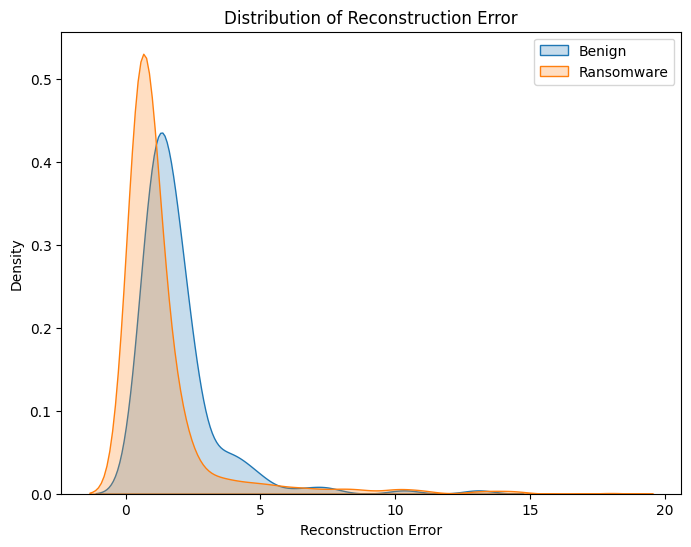

In [366]:
plt.figure(figsize=(8,6))
sns.kdeplot([x for x in lstm_vae_val_reconstruc_losses_180s if x < 20], label="Benign", fill=True)
sns.kdeplot([x for x in lstm_vae_test_reconstruc_losses_180s if x < 20], label="Ransomware", fill=True)
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Distribution of Reconstruction Error")
plt.legend()
plt.show()